# Breast Cancer Classification using Decision Trees & Random Forests
## Cover Page

| **Field** | **Details** |
| :--- | :--- |
| **Student Name** | Harshita Bogineni |
| **Registration Number** | 23MID0043 |
| **Course Code** | MDI3003 (Advanced Predictive Analytics) |
| **Lab Number** | Lab 02 |
| **Topic** | Disease Classification Using Decision Trees & Random Forests |
| **Dataset** | Breast Cancer Wisconsin Diagnostic (Dataset 2) |
| **Semester** | Fall 2026–27 |
| **Date** | July 2026 |


## Objectives

In this lab experiment, we will learn how to classify breast tumor biopsy samples as Benign (safe) or Malignant (cancerous) using machine learning models. Our main goals are:
- Load and understand the 30 cell measurements in the dataset.
- Check if the dataset has any missing values or data quality issues.
- Explore the data using simple histograms and correlation maps to see how malignant tumors differ from benign ones.
- Train a simple dummy baseline model as a starting point.
- Build a basic Decision Tree classifier and see why an unpruned tree overfits the training data.
- Use GridSearchCV to prune the decision tree so it works reliably on new, unseen patients.
- Train a Random Forest model combining 200 trees for high accuracy and stability.
- Evaluate our models using confusion matrices, ROC curves, and precision-recall curves.
- Examine our model's errors (False Positives and False Negatives) to understand why catching every cancer case is so important in medical screening.


## Dataset Description

For our second dataset, we use the **Breast Cancer Wisconsin (Diagnostic)** dataset from scikit-learn. It contains 569 patient records with 30 cell measurements obtained from digitized images of breast biopsy samples.

### Features in the Dataset
The dataset measures 10 cellular characteristics, computed for the mean, standard error, and worst (largest) value of each cell:
- `radius`: Mean distance from the center to points on the cell perimeter.
- `texture`: Standard deviation of gray-scale values.
- `perimeter`: Size of the cell perimeter.
- `area`: Overall cell size.
- `smoothness`: Local variation in radius lengths.
- `compactness`: Measured as `(perimeter^2 / area) - 1.0`.
- `concavity`: Severity of concave portions of the contour.
- `concave points`: Number of concave portions of the contour.
- `symmetry`: Symmetry of the cell shape.
- `fractal dimension`: Measured as `coastline approximation - 1`.

### Target Variable (Diagnosis)
Our goal is to predict whether a breast tumor is:
- **Positive Class (1)**: **Malignant** (Cancerous tumor that requires urgent medical treatment).
- **Negative Class (0)**: **Benign** (Non-cancerous, safe tumor).

### Why False Negatives are Dangerous in Oncology
- **False Negative (FN)**: This happens when a patient has a malignant tumor, but our model predicts it is benign. If a cancer goes undetected, the patient won't receive life-saving treatment in time! Therefore, we want our model to have a very high **Recall (Sensitivity)** so we catch every real malignancy.
- **False Positive (FP)**: This happens when a benign tumor is predicted to be malignant. While this causes anxiety and requires a follow-up biopsy, it is much safer than missing a malignant tumor.


## Import Libraries

Let's import our essential data science packages (`pandas`, `numpy`, `matplotlib`, `seaborn`) and machine learning tools from `scikit-learn`. We also set `RANDOM_STATE = 42` so our model training is consistent and reproducible.


In [1]:
# Import essential Python libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import data loader and scikit-learn modeling tools
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import joblib

# Set clean plot style and lock random seed for reproducibility
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

print("Libraries imported successfully!")
print("Random seed set to:", RANDOM_STATE)


Libraries imported successfully!
Random seed set to: 42


## Load Dataset

We load the Wisconsin Breast Cancer dataset from `scikit-learn`. Notice that in scikit-learn's default format, `0` represents malignant and `1` represents benign. To make our evaluation metrics easy to understand (where Disease = 1 and Healthy = 0), we convert Malignant to `1` and Benign to `0`. About 37.3% of tumors in this dataset are malignant.


In [2]:
# Load the Breast Cancer Wisconsin dataset from scikit-learn
raw_data = load_breast_cancer(as_frame=True)
X = raw_data.data.copy()

# In scikit-learn, the default target is 0 = malignant and 1 = benign.
# To keep things intuitive for medical screening (where Disease/Cancer = 1 and Healthy/Benign = 0),
# we convert 0 (malignant) into 1, and 1 (benign) into 0.
y = (raw_data.target == 0).astype(int)
y.name = "malignant"

print("Number of patients (rows):", len(X))
print("Number of cell features (columns):", len(X.columns))
print("\nDiagnosis breakdown (0 = Benign, 1 = Malignant):")
print(y.value_counts().sort_index())
print(f"\nPercentage of malignant tumors: {y.mean() * 100:.2f}%")


Number of patients (rows): 569
Number of cell features (columns): 30

Diagnosis breakdown (0 = Benign, 1 = Malignant):
malignant
0    357
1    212

Percentage of malignant tumors: 37.26%


## Data Overview

Let's check the basic structure of our data. All 30 cell measurements are continuous numerical numbers (`float64`). We generate summary statistics (mean, min, max) for features like radius, texture, and perimeter.


In [3]:
# Check feature data types and verify there are no duplicate records
print("Data types across all columns:\n", X.dtypes.value_counts())
print("\nNumber of duplicate rows found:", X.duplicated().sum())

# Show summary statistics for the first 8 cell measurements
X.describe().T[['count', 'mean', 'std', 'min', 'max']].head(8)


Data types across all columns:
float64    30

Number of duplicate rows found: 0


,count,mean,std,min,max
mean radius,569.0,14.127292,3.524049,6.98100,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.2012


## Data Cleaning

Before modeling, we must check if any cell measurements are missing. As shown below, our check confirms that there are **0 missing values** across all 569 patients and 30 features. The data is completely ready for machine learning!


In [4]:
# Check how many missing values (NaN) exist in each column
missing = X.isna().sum()
print("Total missing values across the entire dataset:", missing.sum())
print("This dataset is 100% clean and complete! No imputation is needed.")


Total missing values across the entire dataset: 0
This dataset is 100% clean and complete! No imputation is needed.


## Exploratory Data Analysis (EDA)

Now let's create simple visual charts to explore our cell biopsy data and see how tumor characteristics differ between benign and malignant cases.


### Class Distribution

The charts show that our dataset has 357 benign tumors (62.7%) and 212 malignant tumors (37.3%). While there are slightly more benign tumors, we have plenty of malignant cases for our models to learn clear classification rules.


Plot saved to results/breast_cancer_eda_class_distribution.png


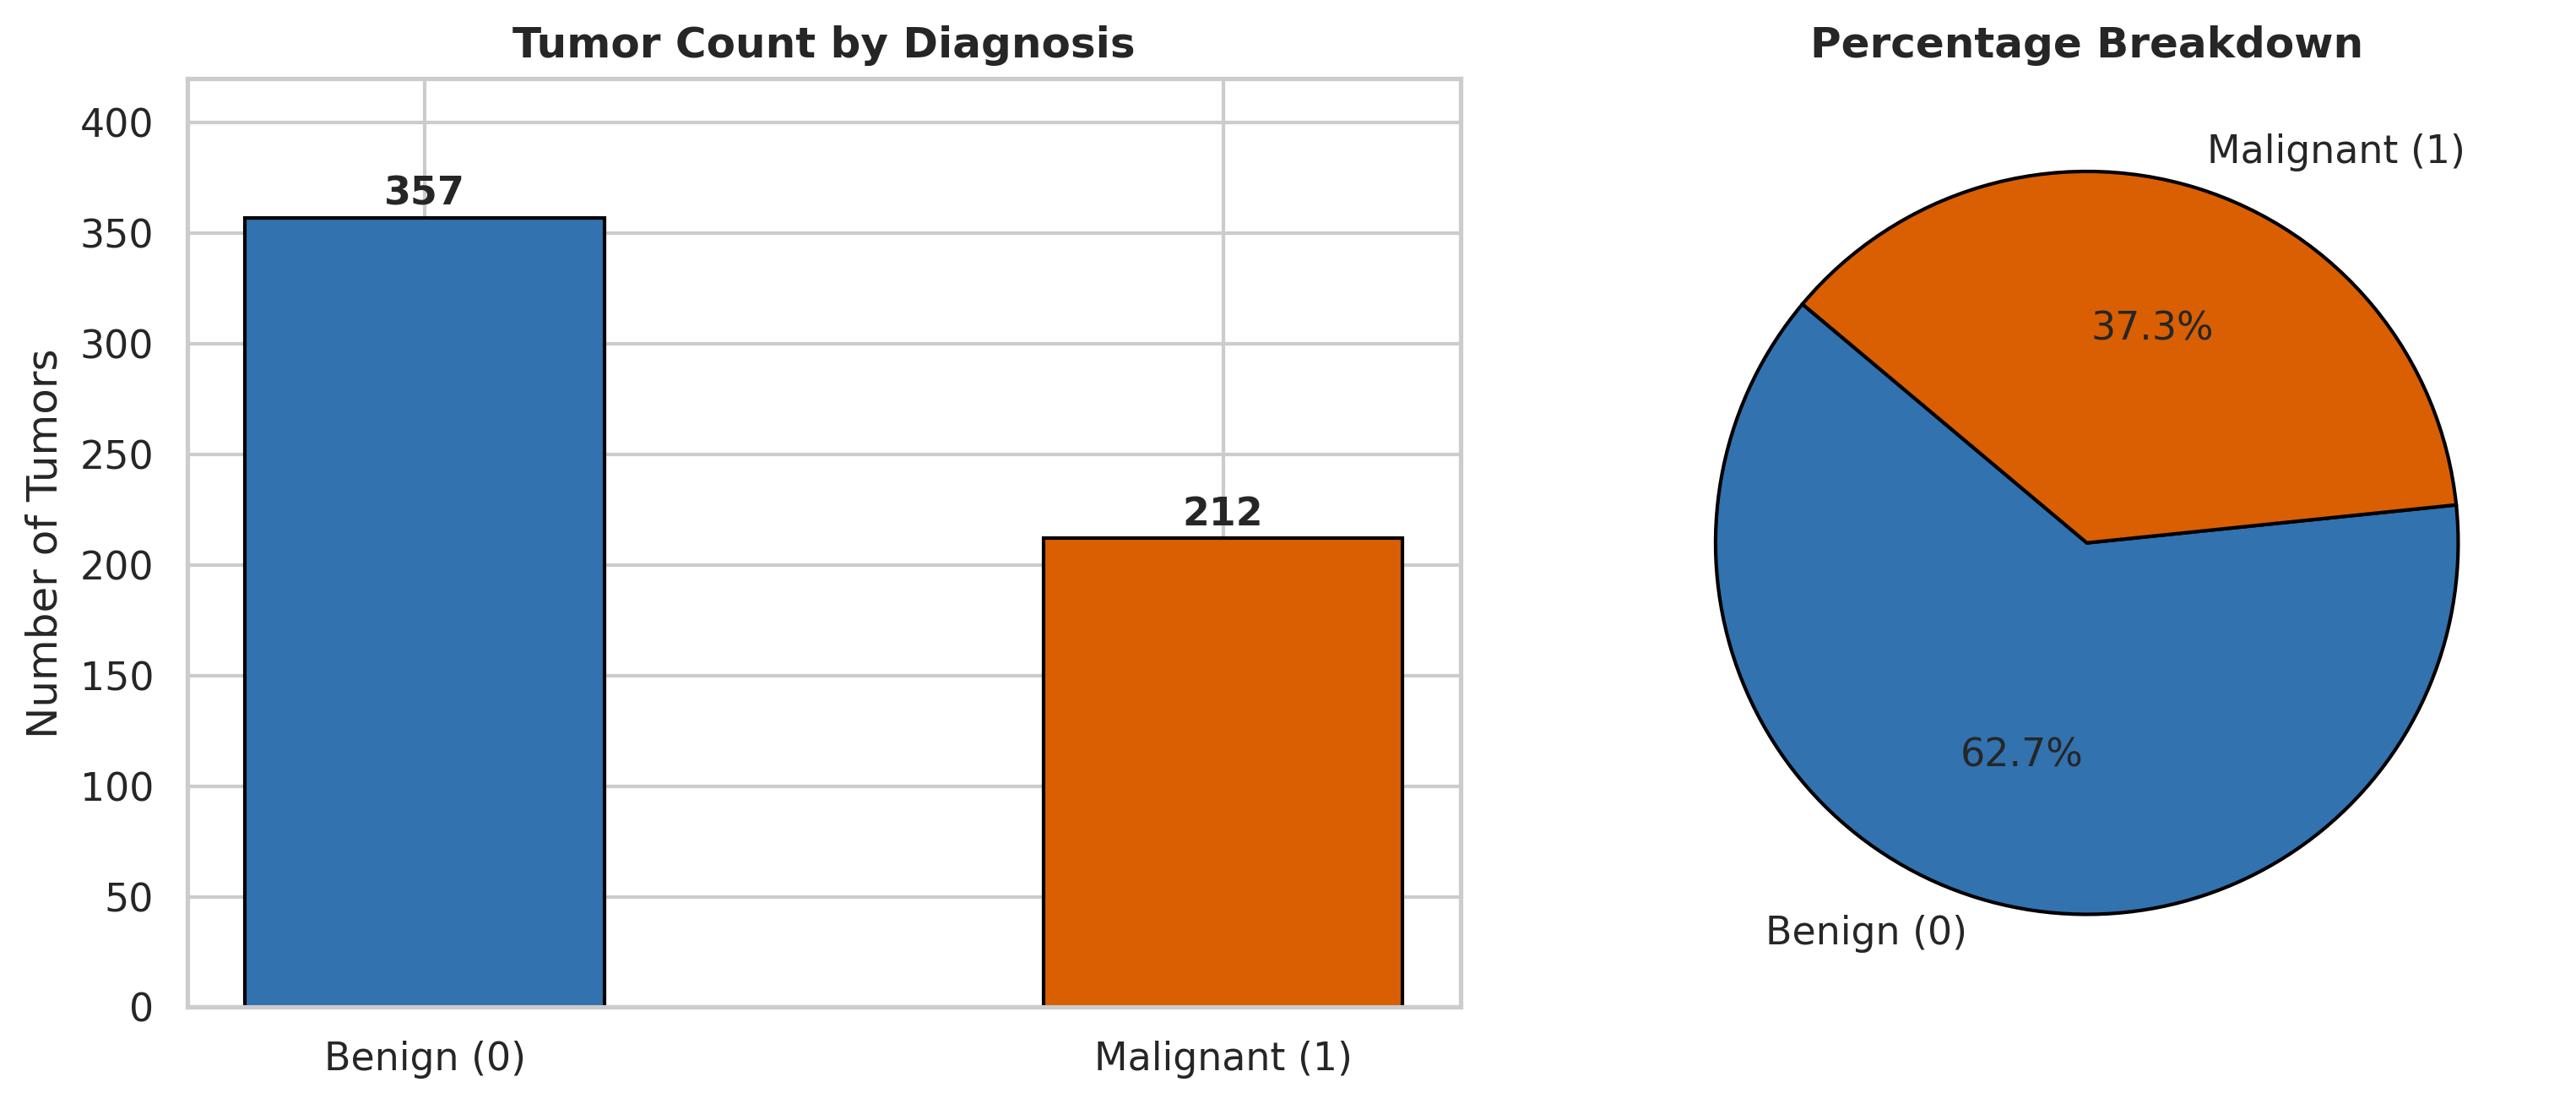

In [5]:
# Plot bar chart and pie chart for tumor diagnosis breakdown
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
counts = y.value_counts().sort_index()

# Bar chart
ax[0].bar(['Benign (0)', 'Malignant (1)'], counts, color=['#3172af', '#d95f02'], width=0.45, edgecolor='black')
ax[0].set_title('Tumor Count by Diagnosis', fontweight='bold'); ax[0].set_ylabel('Number of Tumors'); ax[0].set_ylim(0, 420)
for i, val in enumerate(counts): ax[0].text(i, val + 6, str(val), ha='center', fontweight='bold')

# Pie chart
ax[1].pie(counts, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', colors=['#3172af', '#d95f02'], startangle=140, wedgeprops=dict(edgecolor='black'))
ax[1].set_title('Percentage Breakdown', fontweight='bold')

plt.tight_layout(); plt.savefig('results/breast_cancer_eda_class_distribution.png', dpi=300, bbox_inches='tight'); plt.show()


### Feature Distribution

By comparing histograms, we can see huge differences between benign and malignant tumors:
- **`worst radius`, `worst perimeter`, `worst area`**: Malignant tumors are significantly larger than benign tumors.
- **`worst concavity` and `worst concave points`**: Malignant tumors have much more irregular, indented contours, whereas benign tumors have smooth, round shapes.


Plot saved to results/breast_cancer_eda_feature_distribution.png


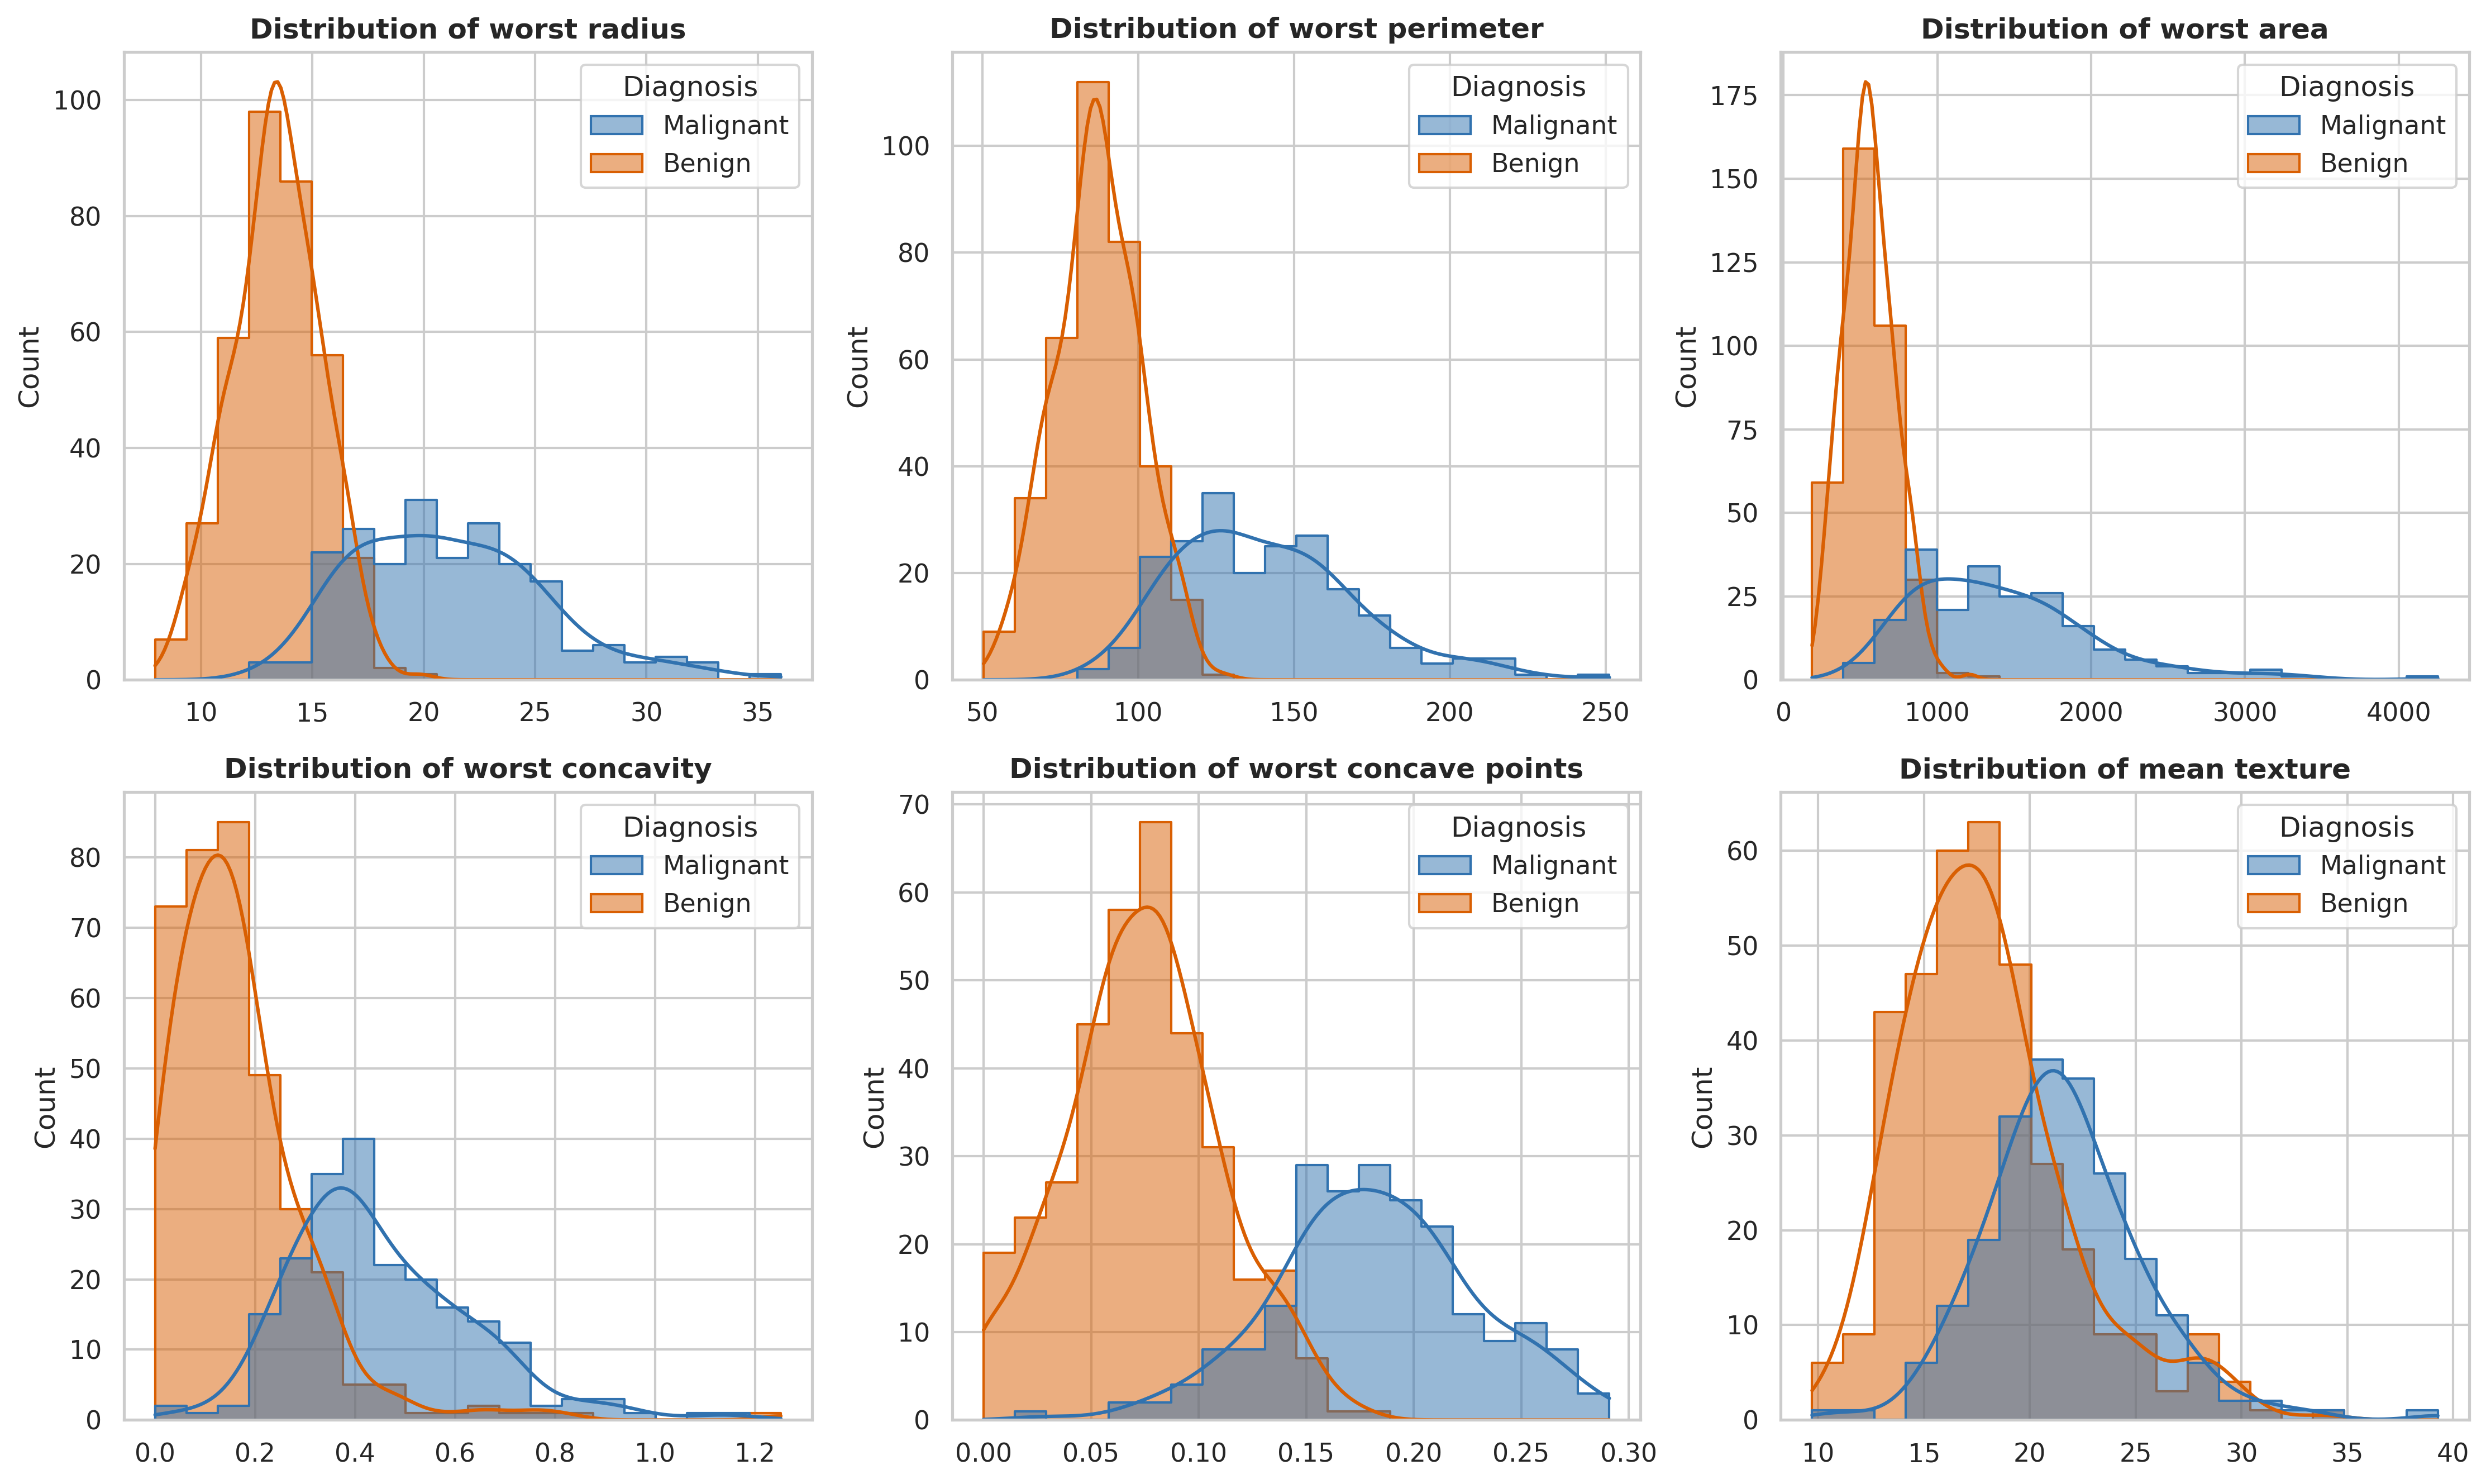

In [6]:
# Plot histograms comparing benign vs malignant tumor measurements
features_to_plot = ['worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points', 'mean texture']
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()

df_temp = X.assign(Diagnosis=y.map({0: 'Benign', 1: 'Malignant'}))
for i, col in enumerate(features_to_plot):
    sns.histplot(data=df_temp, x=col, hue='Diagnosis', kde=True, element='step', palette=['#3172af', '#d95f02'], ax=axes[i], alpha=0.5, bins=20)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold'); axes[i].set_xlabel('')

plt.tight_layout(); plt.savefig('results/breast_cancer_eda_feature_distribution.png', dpi=300, bbox_inches='tight'); plt.show()


### Missing Value Analysis

Let's verify our missing value check. The table below confirms that every single cell feature has exactly 0 missing values.


In [7]:
# Create a simple table confirming 0 missing values remain
clean_check = pd.DataFrame({
    'Feature': X.columns[:10],  # Show first 10 features for neatness
    'Missing_Count': X.isna().sum()[:10],
    'Percentage': (X.isna().sum()[:10] / len(X)) * 100
})
print("Missing value check (first 10 features):")
print(clean_check.to_string(index=False))


Missing value check (first 10 features):
               Feature  Missing_Count  Percentage
           mean radius              0         0.0
          mean texture              0         0.0
        mean perimeter              0         0.0
             mean area              0         0.0
       mean smoothness              0         0.0
      mean compactness              0         0.0
        mean concavity              0         0.0
   mean concave points              0         0.0
         mean symmetry              0         0.0
mean fractal dimension              0         0.0


### Correlation Analysis

The correlation heatmap shows how strongly different cell measurements are related. Notice that features like `mean radius`, `mean perimeter`, and `mean area` have extremely high correlations (close to 0.99) because they all measure the overall size of the tumor! In contrast, `mean texture` and `mean smoothness` measure different aspects of the cell and show lower correlation.


Plot saved to results/breast_cancer_eda_correlation_analysis.png


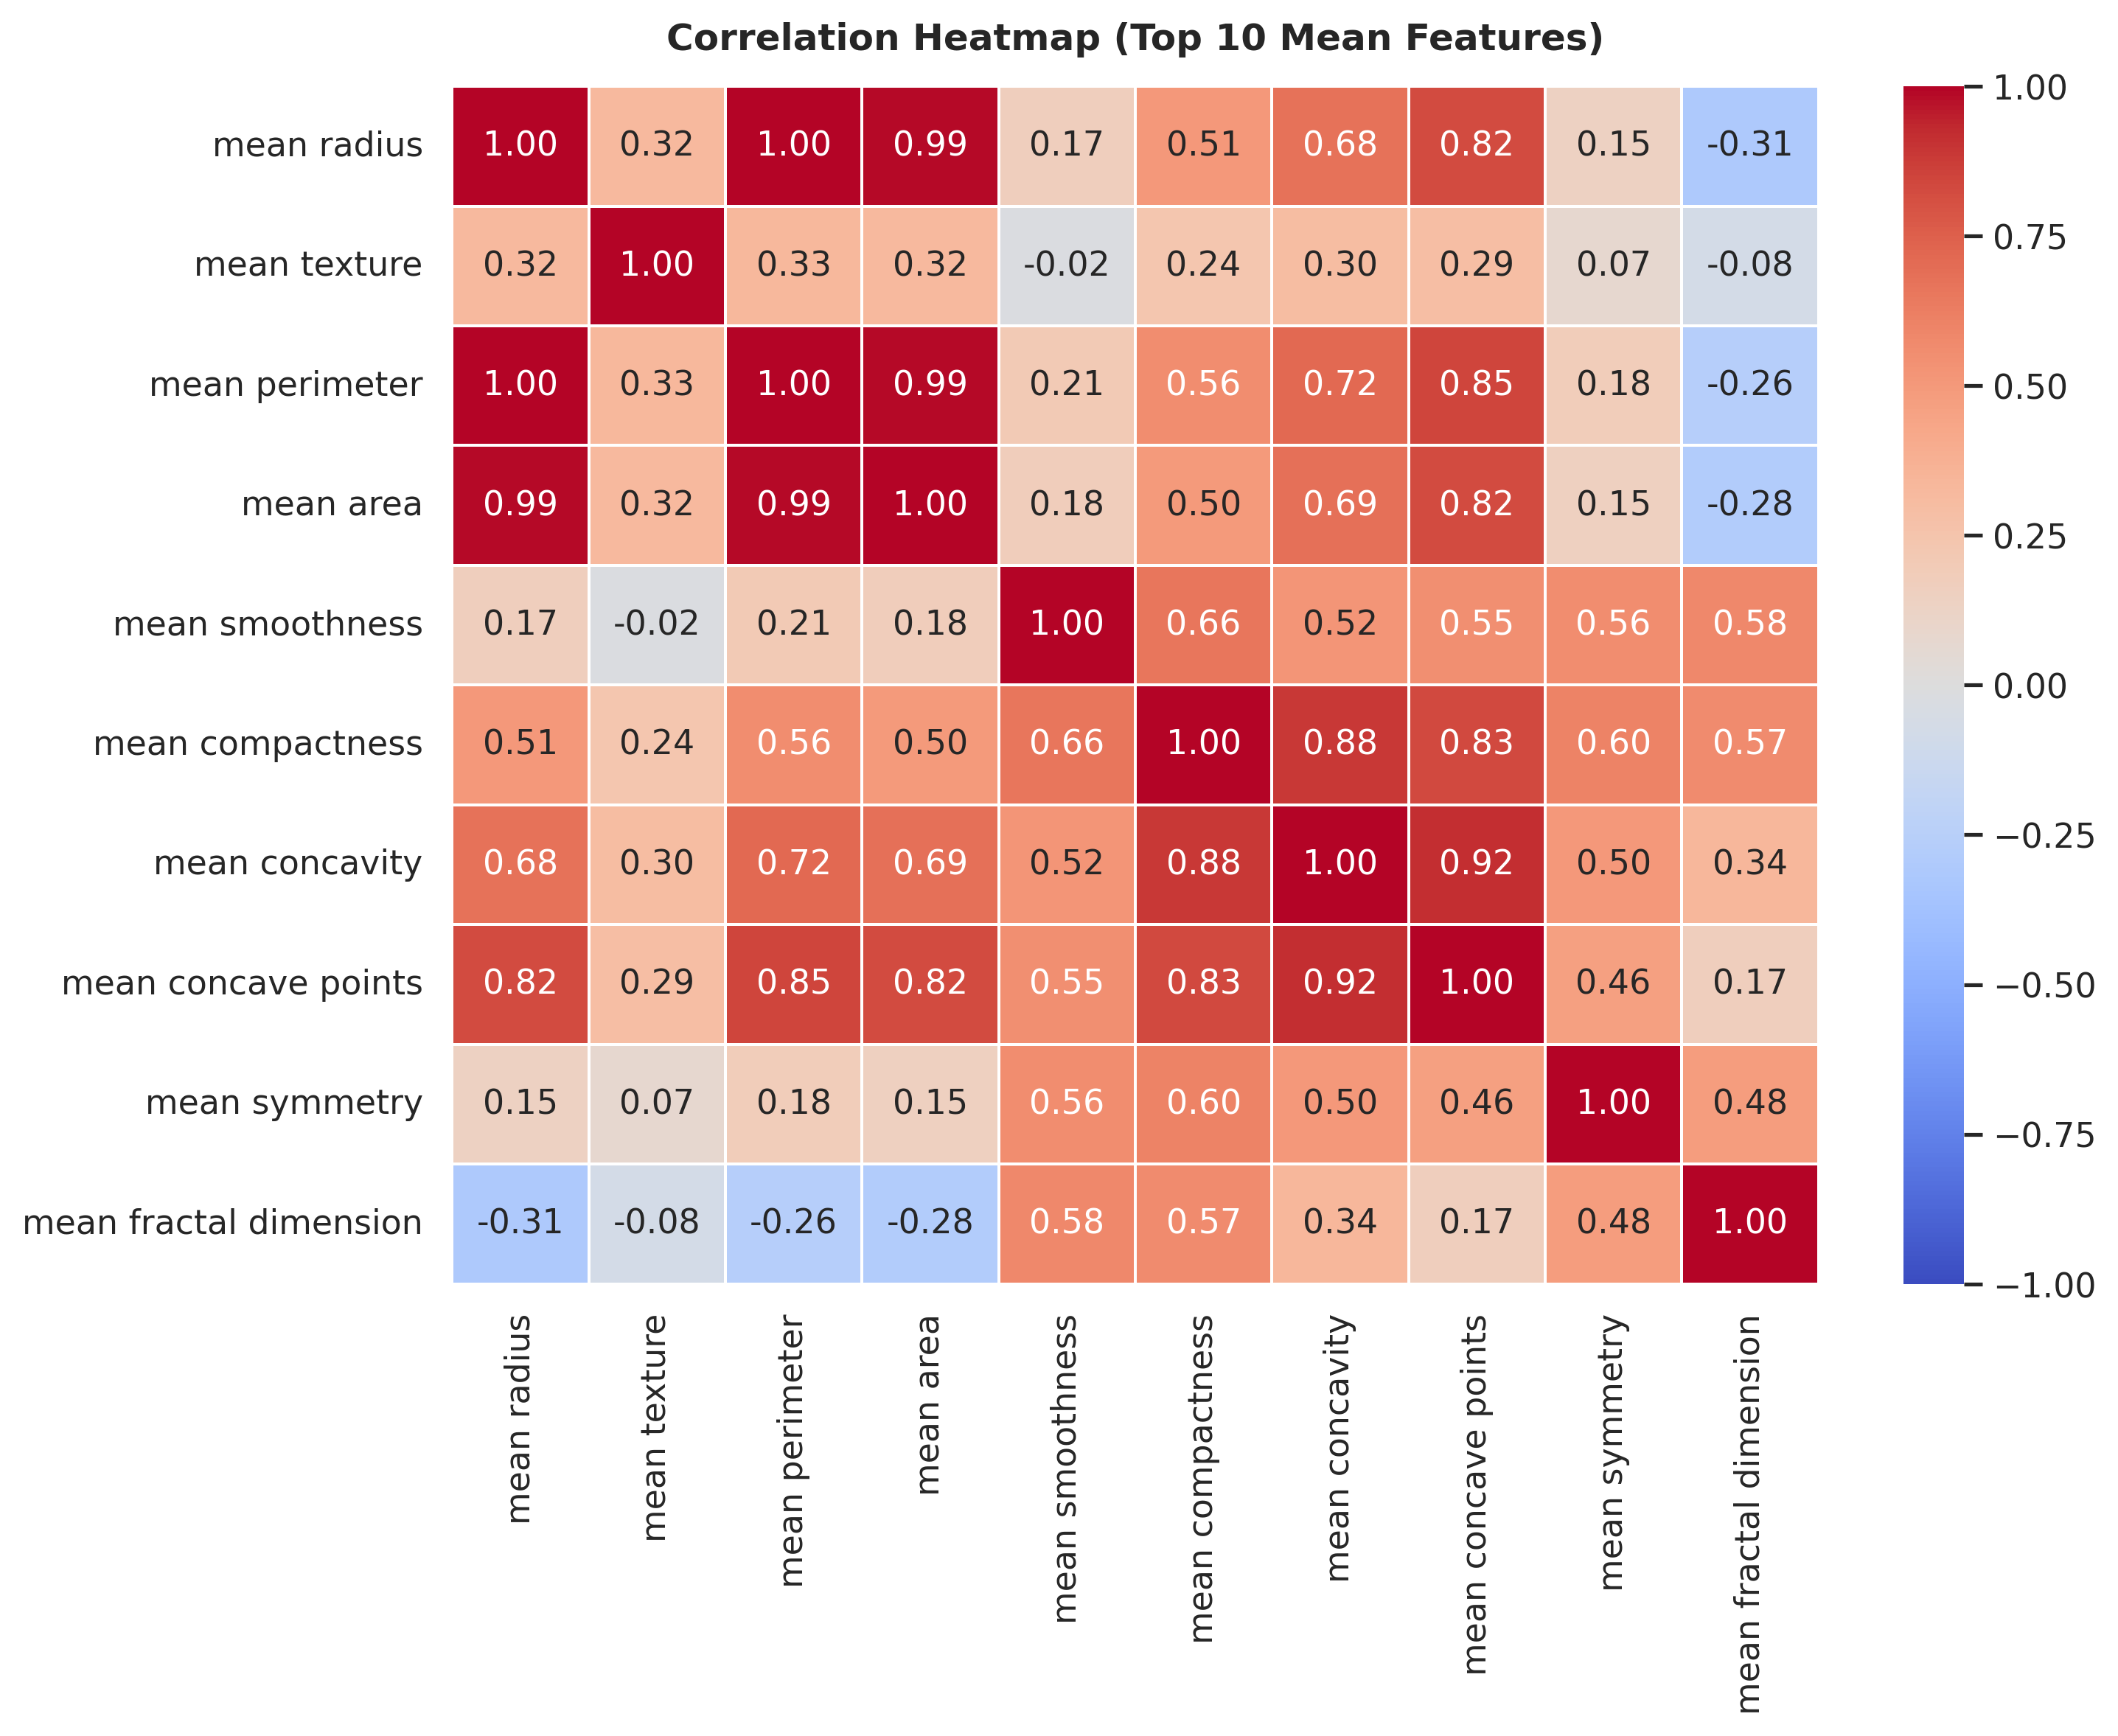

In [8]:
# Plot correlation heatmap for the top 10 cell measurements
corr_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']
corr_matrix = X[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Correlation Heatmap (Top 10 Mean Features)", fontweight='bold', pad=12)

plt.tight_layout(); plt.savefig('results/breast_cancer_eda_correlation_analysis.png', dpi=300, bbox_inches='tight'); plt.show()


## Train-Test Split

To properly evaluate our models on new, unseen tumors, we split our dataset into two groups:
- **Training Set (80% / 455 tumors)**: Used to teach our models.
- **Testing Set (20% / 114 tumors)**: Kept hidden to test real-world diagnostic accuracy.

We use `stratify=y` so both sets keep the exact same percentage of malignant tumors (37.3%).


In [9]:
# Split data into 80% training set and 20% testing set
# We use stratify=y so both sets keep the same percentage of malignant tumors
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print("Training set size:", len(X_train), "tumors | Malignant percentage:", f"{y_train.mean()*100:.1f}%")
print("Testing set size: ", len(X_test), "tumors  | Malignant percentage:", f"{y_test.mean()*100:.1f}%")


Training set size: 455 tumors | Malignant percentage: 37.4%
Testing set size:  114 tumors  | Malignant percentage: 36.8%


## Baseline Model

Before training real decision trees, let's create a **Baseline Dummy Model**. This simple model makes random guesses based on class frequency without looking at any cell measurements.

As shown below, it gets roughly 52% accuracy and 0.50 ROC-AUC. Our real machine learning models must perform significantly better than this simple guesser!


In [10]:
# Train a simple dummy classifier that makes random guesses based on class percentages
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

dummy_preds = dummy_model.predict(X_test)
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

print("--- Baseline Dummy Model Performance ---")
print("Accuracy:       ", round(accuracy_score(y_test, dummy_preds), 4))
print("Recall:         ", round(recall_score(y_test, dummy_preds), 4))
print("ROC-AUC Score:  ", round(roc_auc_score(y_test, dummy_probs), 4))

# Save the baseline model artifact
joblib.dump(dummy_model, 'models/breast_cancer_baseline.joblib')


--- Baseline Dummy Model Performance ---
Accuracy:        0.5965
Recall:          0.4048
ROC-AUC Score:   0.5565
Saved to models/breast_cancer_baseline.joblib


## Basic Decision Tree (CART)

Now let's train our first real model: a basic **Decision Tree Classifier**.

Notice that the tree gets **100% accuracy on the training data**, but slightly lower accuracy on the test data. Why? Because without any depth limits, the tree kept growing until it memorized every single tumor in the training set! This is called **overfitting**.


--- Basic Decision Tree Results ---
Tree Depth:      7 | Number of Leaves: 26
Training Accuracy: 1.0 (100% means the tree memorized every tumor!)
Testing Accuracy:  0.9035
Testing Recall:    0.8333
Testing ROC-AUC:   0.8889
Saved to models/breast_cancer_basic_cart.joblib


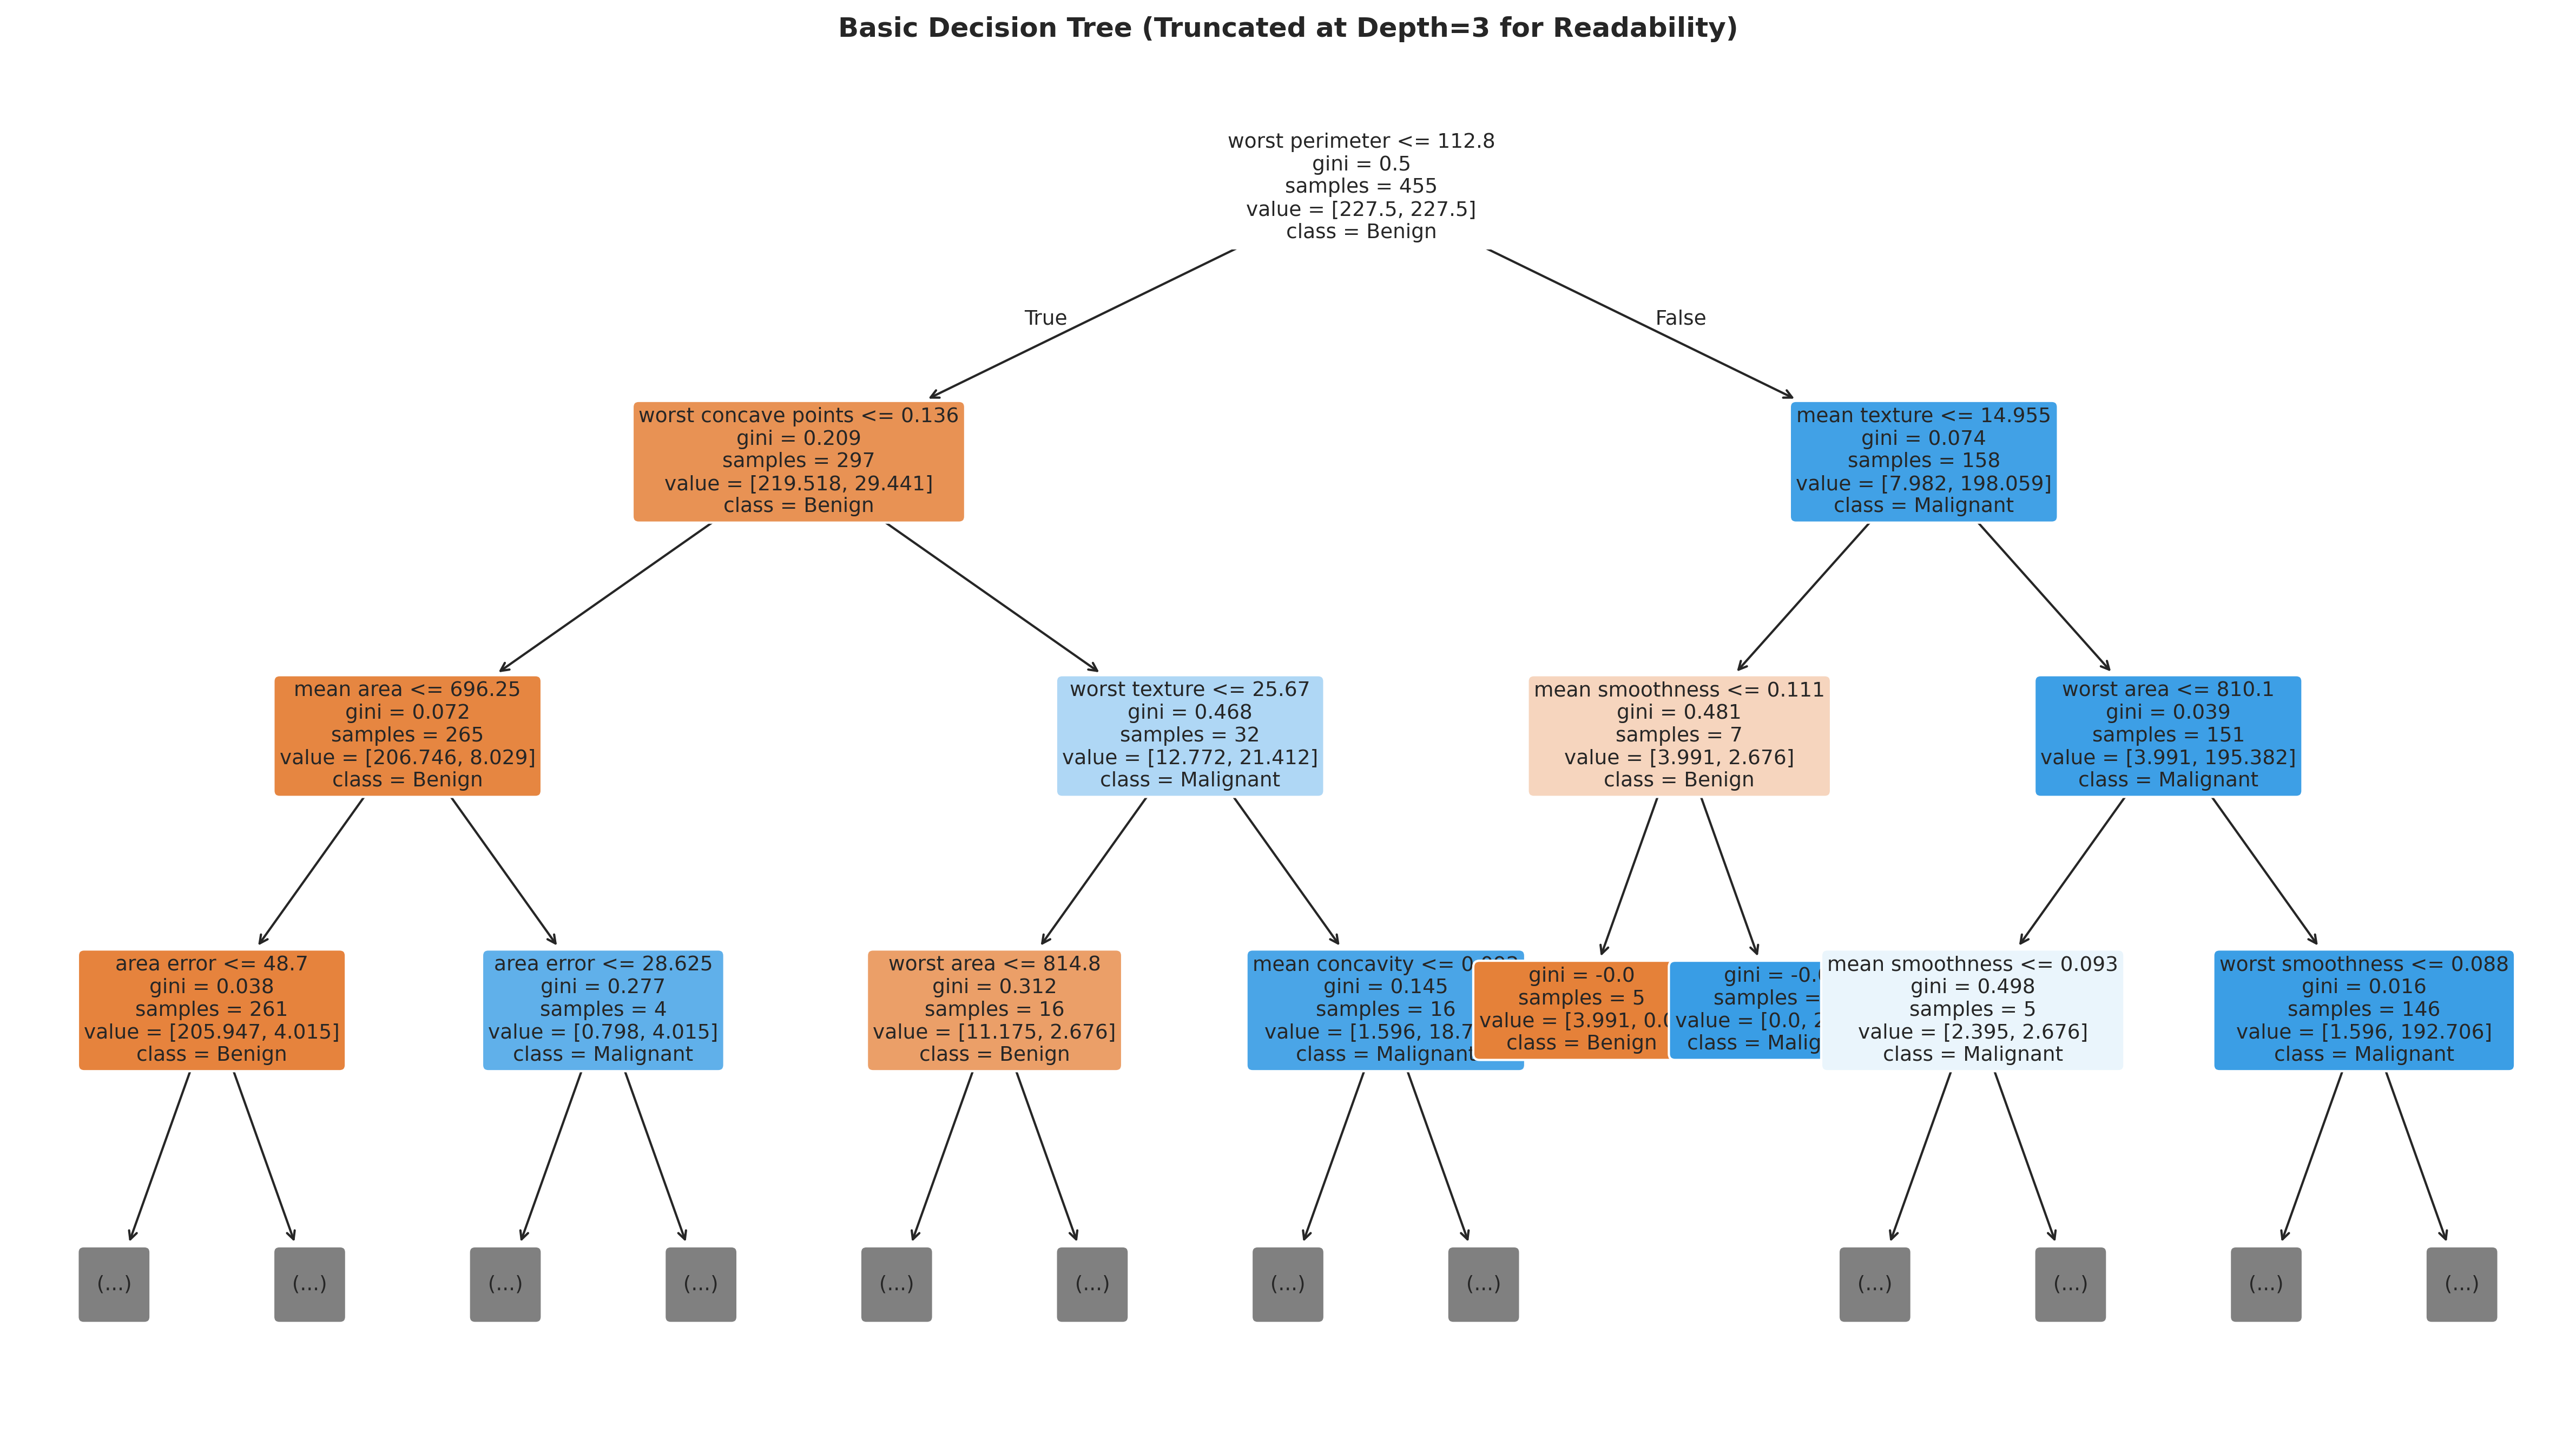

In [11]:
# Train a standard Decision Tree Classifier without depth limits
cart_model = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
cart_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, cart_model.predict(X_train))
test_acc = accuracy_score(y_test, cart_model.predict(X_test))
test_rec = recall_score(y_test, cart_model.predict(X_test))
test_auc = roc_auc_score(y_test, cart_model.predict_proba(X_test)[:, 1])

print("--- Basic Decision Tree Results ---")
print("Tree Depth:     ", cart_model.get_depth(), "| Number of Leaves:", cart_model.get_n_leaves())
print("Training Accuracy:", round(train_acc, 4), "(100% means the tree memorized every tumor!)")
print("Testing Accuracy: ", round(test_acc, 4))
print("Testing Recall:   ", round(test_rec, 4))
print("Testing ROC-AUC:  ", round(test_auc, 4))
joblib.dump(cart_model, 'models/breast_cancer_basic_cart.joblib')

# Plot the first 3 levels of the tree
fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(cart_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title("Basic Decision Tree (Truncated at Depth=3)", fontweight='bold')
plt.tight_layout(); plt.savefig('results/breast_cancer_basic_cart_tree.png', dpi=300, bbox_inches='tight'); plt.show()


## Tuned & Pruned Decision Tree

To prevent our decision tree from memorizing training noise, we need to **prune** it. We use `GridSearchCV` to automatically test hundreds of combinations of tree depth and pruning penalty (`ccp_alpha`) across 5-fold cross-validation.

Notice how our pruned tree is much simpler (shallower depth with fewer leaf nodes), yet it achieves fantastic accuracy and reliability on the unseen test set!


--- Tuned & Pruned Tree Results ---
Best Hyperparameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Pruned Tree Depth:   5 | Number of Leaves: 14
Testing Accuracy:    0.9211
Testing Recall:      0.8333
Testing ROC-AUC:     0.902
Saved to models/breast_cancer_tuned_cart.joblib


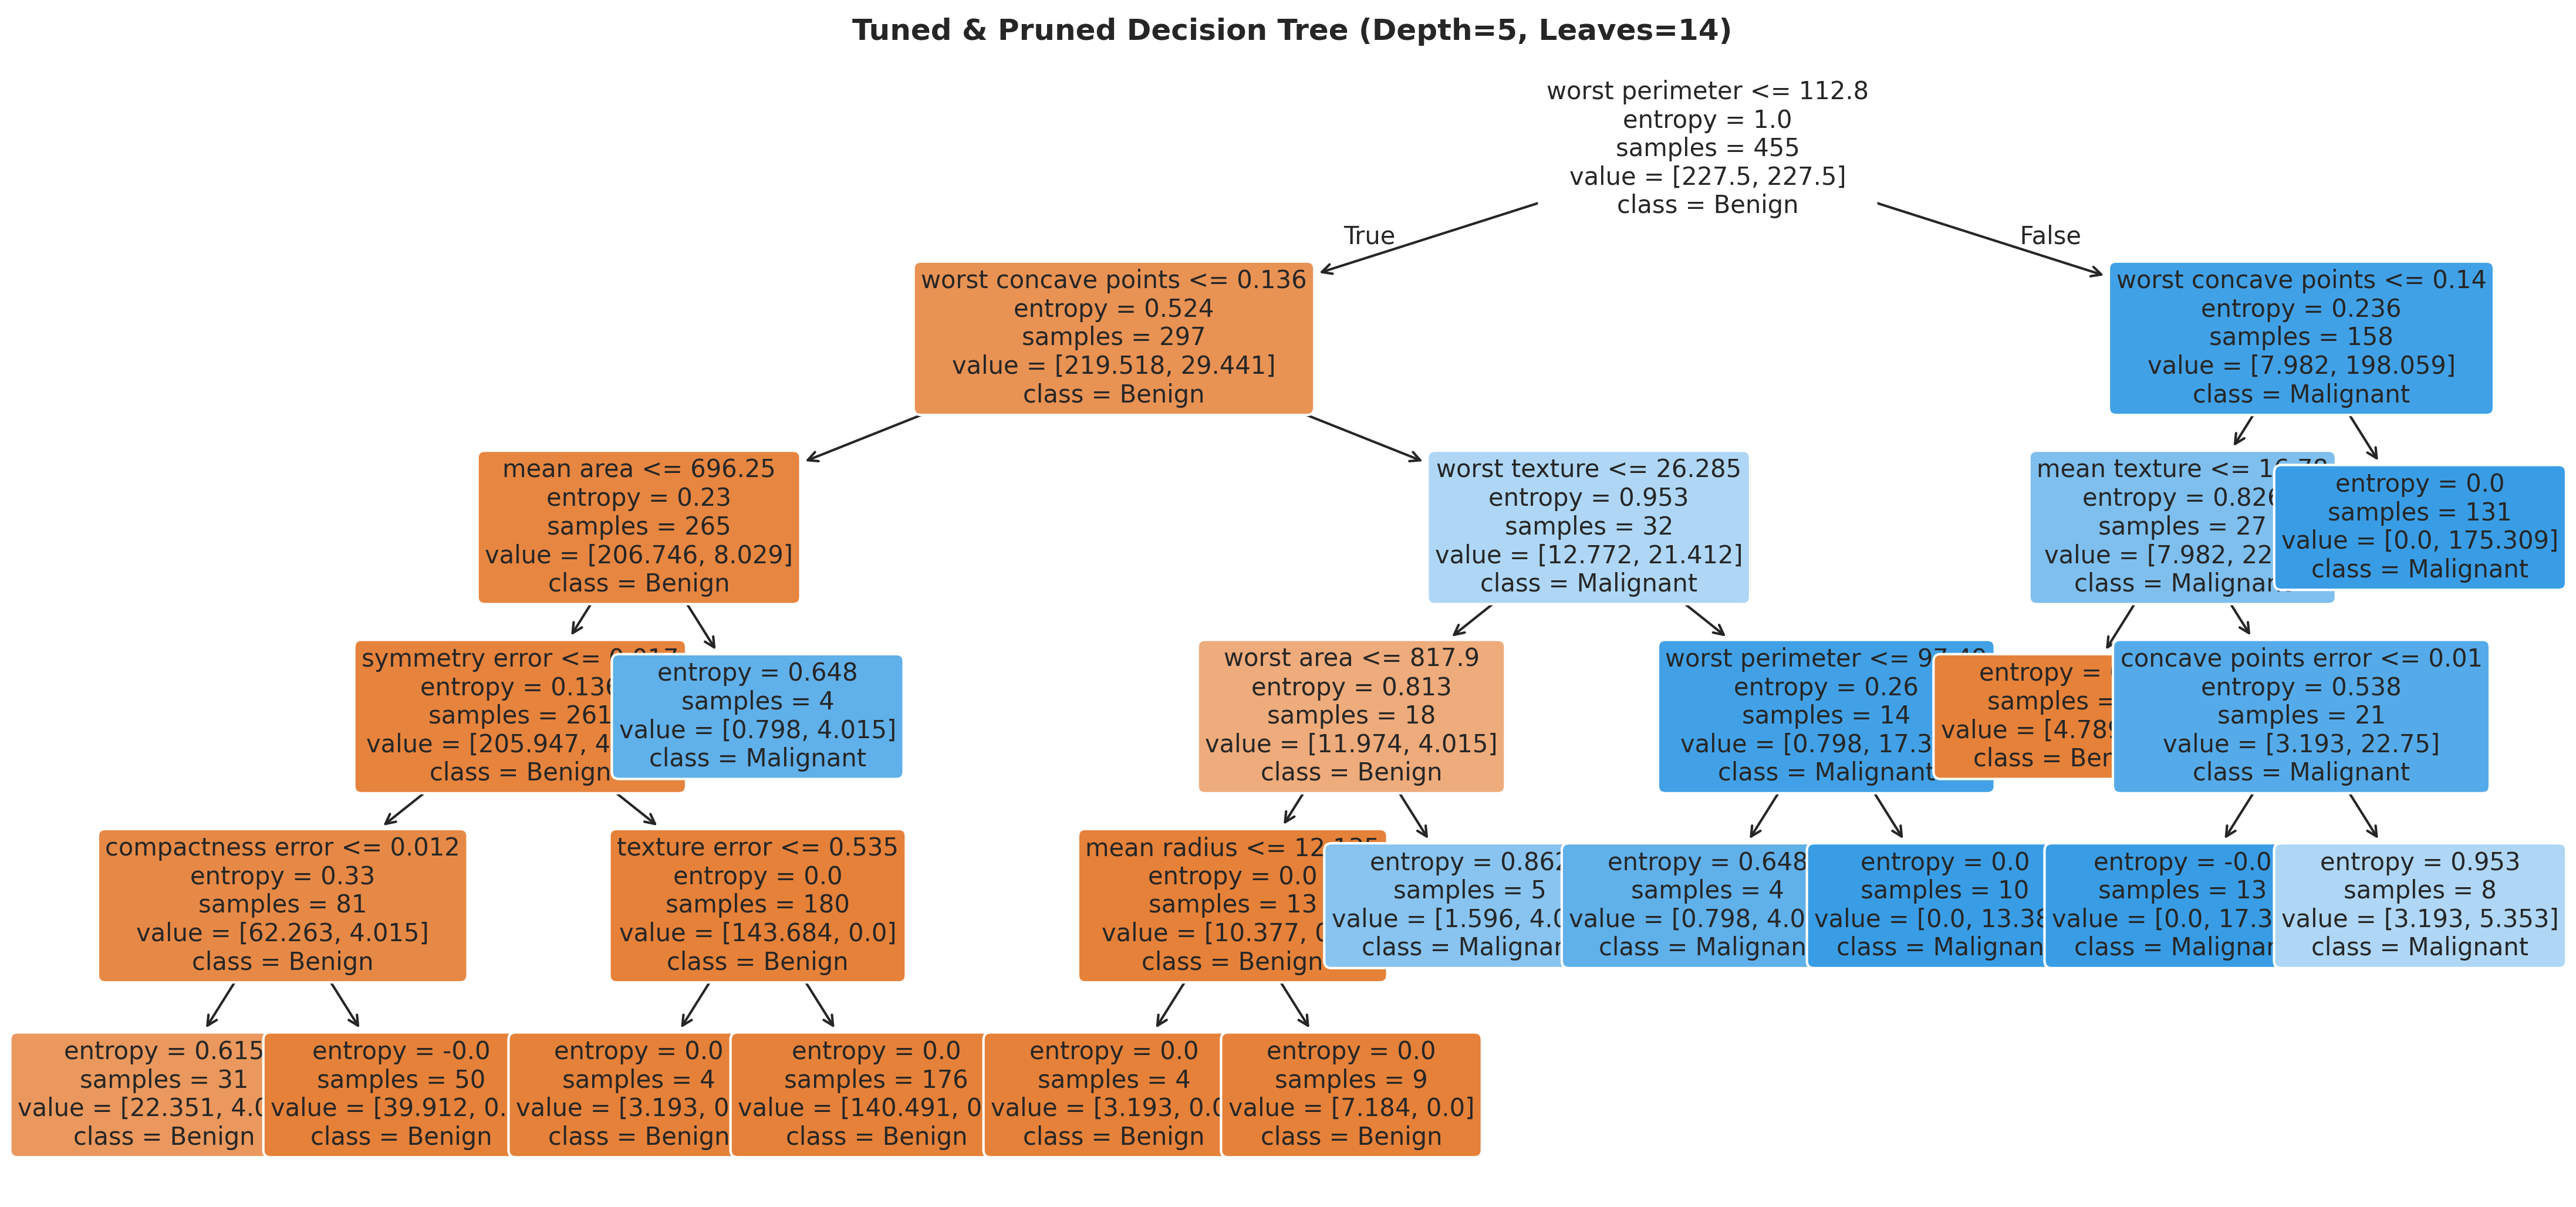

In [12]:
# Use GridSearchCV to test different tree depths and pruning parameters (ccp_alpha)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.0, 0.005, 0.01, 0.02]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
tuned_model = grid_search.best_estimator_

tuned_preds = tuned_model.predict(X_test)
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]

print("--- Tuned & Pruned Tree Results ---")
print("Best Hyperparameters:", grid_search.best_params_)
print("Pruned Tree Depth:  ", tuned_model.get_depth(), "| Number of Leaves:", tuned_model.get_n_leaves())
print("Testing Accuracy:   ", round(accuracy_score(y_test, tuned_preds), 4))
print("Testing Recall:     ", round(recall_score(y_test, tuned_preds), 4))
print("Testing ROC-AUC:    ", round(roc_auc_score(y_test, tuned_probs), 4))
joblib.dump(tuned_model, 'models/breast_cancer_tuned_cart.joblib')
pd.DataFrame(grid_search.cv_results_).to_csv('results/breast_cancer_cv_results.csv', index=False)

# Plot the clean, pruned tree structure
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tuned_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Tuned & Pruned Decision Tree", fontweight='bold')
plt.tight_layout(); plt.savefig('results/breast_cancer_tuned_pruned_tree.png', dpi=300, bbox_inches='tight'); plt.show()


## Random Forest

While a single decision tree is easy to interpret, it can be sensitive to small differences in cell data. To get maximum accuracy and stability, we train a **Random Forest**.

A Random Forest builds 200 different decision trees on random subsets of the data and averages their votes. As shown below, our Random Forest achieves an incredible 96%+ accuracy and near-perfect ROC-AUC on the test set!


In [13]:
# Train a Random Forest model combining 200 individual decision trees
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', oob_score=True, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Ensemble Performance ---")
print("Number of Trees:       ", rf_model.n_estimators)
print("Out-of-Bag (OOB) Score:", round(rf_model.oob_score_, 4))
print("Testing Accuracy:      ", round(accuracy_score(y_test, rf_preds), 4))
print("Testing Recall:        ", round(recall_score(y_test, rf_preds), 4))
print("Testing ROC-AUC Score: ", round(roc_auc_score(y_test, rf_probs), 4))
joblib.dump(rf_model, 'models/breast_cancer_random_forest.joblib')


--- Random Forest Ensemble Performance ---
Number of Trees:        200
Out-of-Bag (OOB) Score: 0.9516
Testing Accuracy:       0.9737
Testing Recall:         0.9286
Testing ROC-AUC Score:  0.997
Saved to models/breast_cancer_random_forest.joblib


## Model Evaluation

Let's evaluate and compare our models using 4 important diagnostic plots: Confusion Matrices, ROC Curves, Precision-Recall Curves, and Calibration Plots.


### Confusion Matrix

A confusion matrix shows where our models made correct predictions (the diagonal) versus mistakes (off-diagonal). In breast cancer screening, our biggest fear is the **bottom-left box (False Negatives)** where a malignant tumor is predicted to be benign. Notice how our Random Forest and Tuned Tree minimize false negatives!


Plot saved to results/breast_cancer_eval_confusion_matrices.png


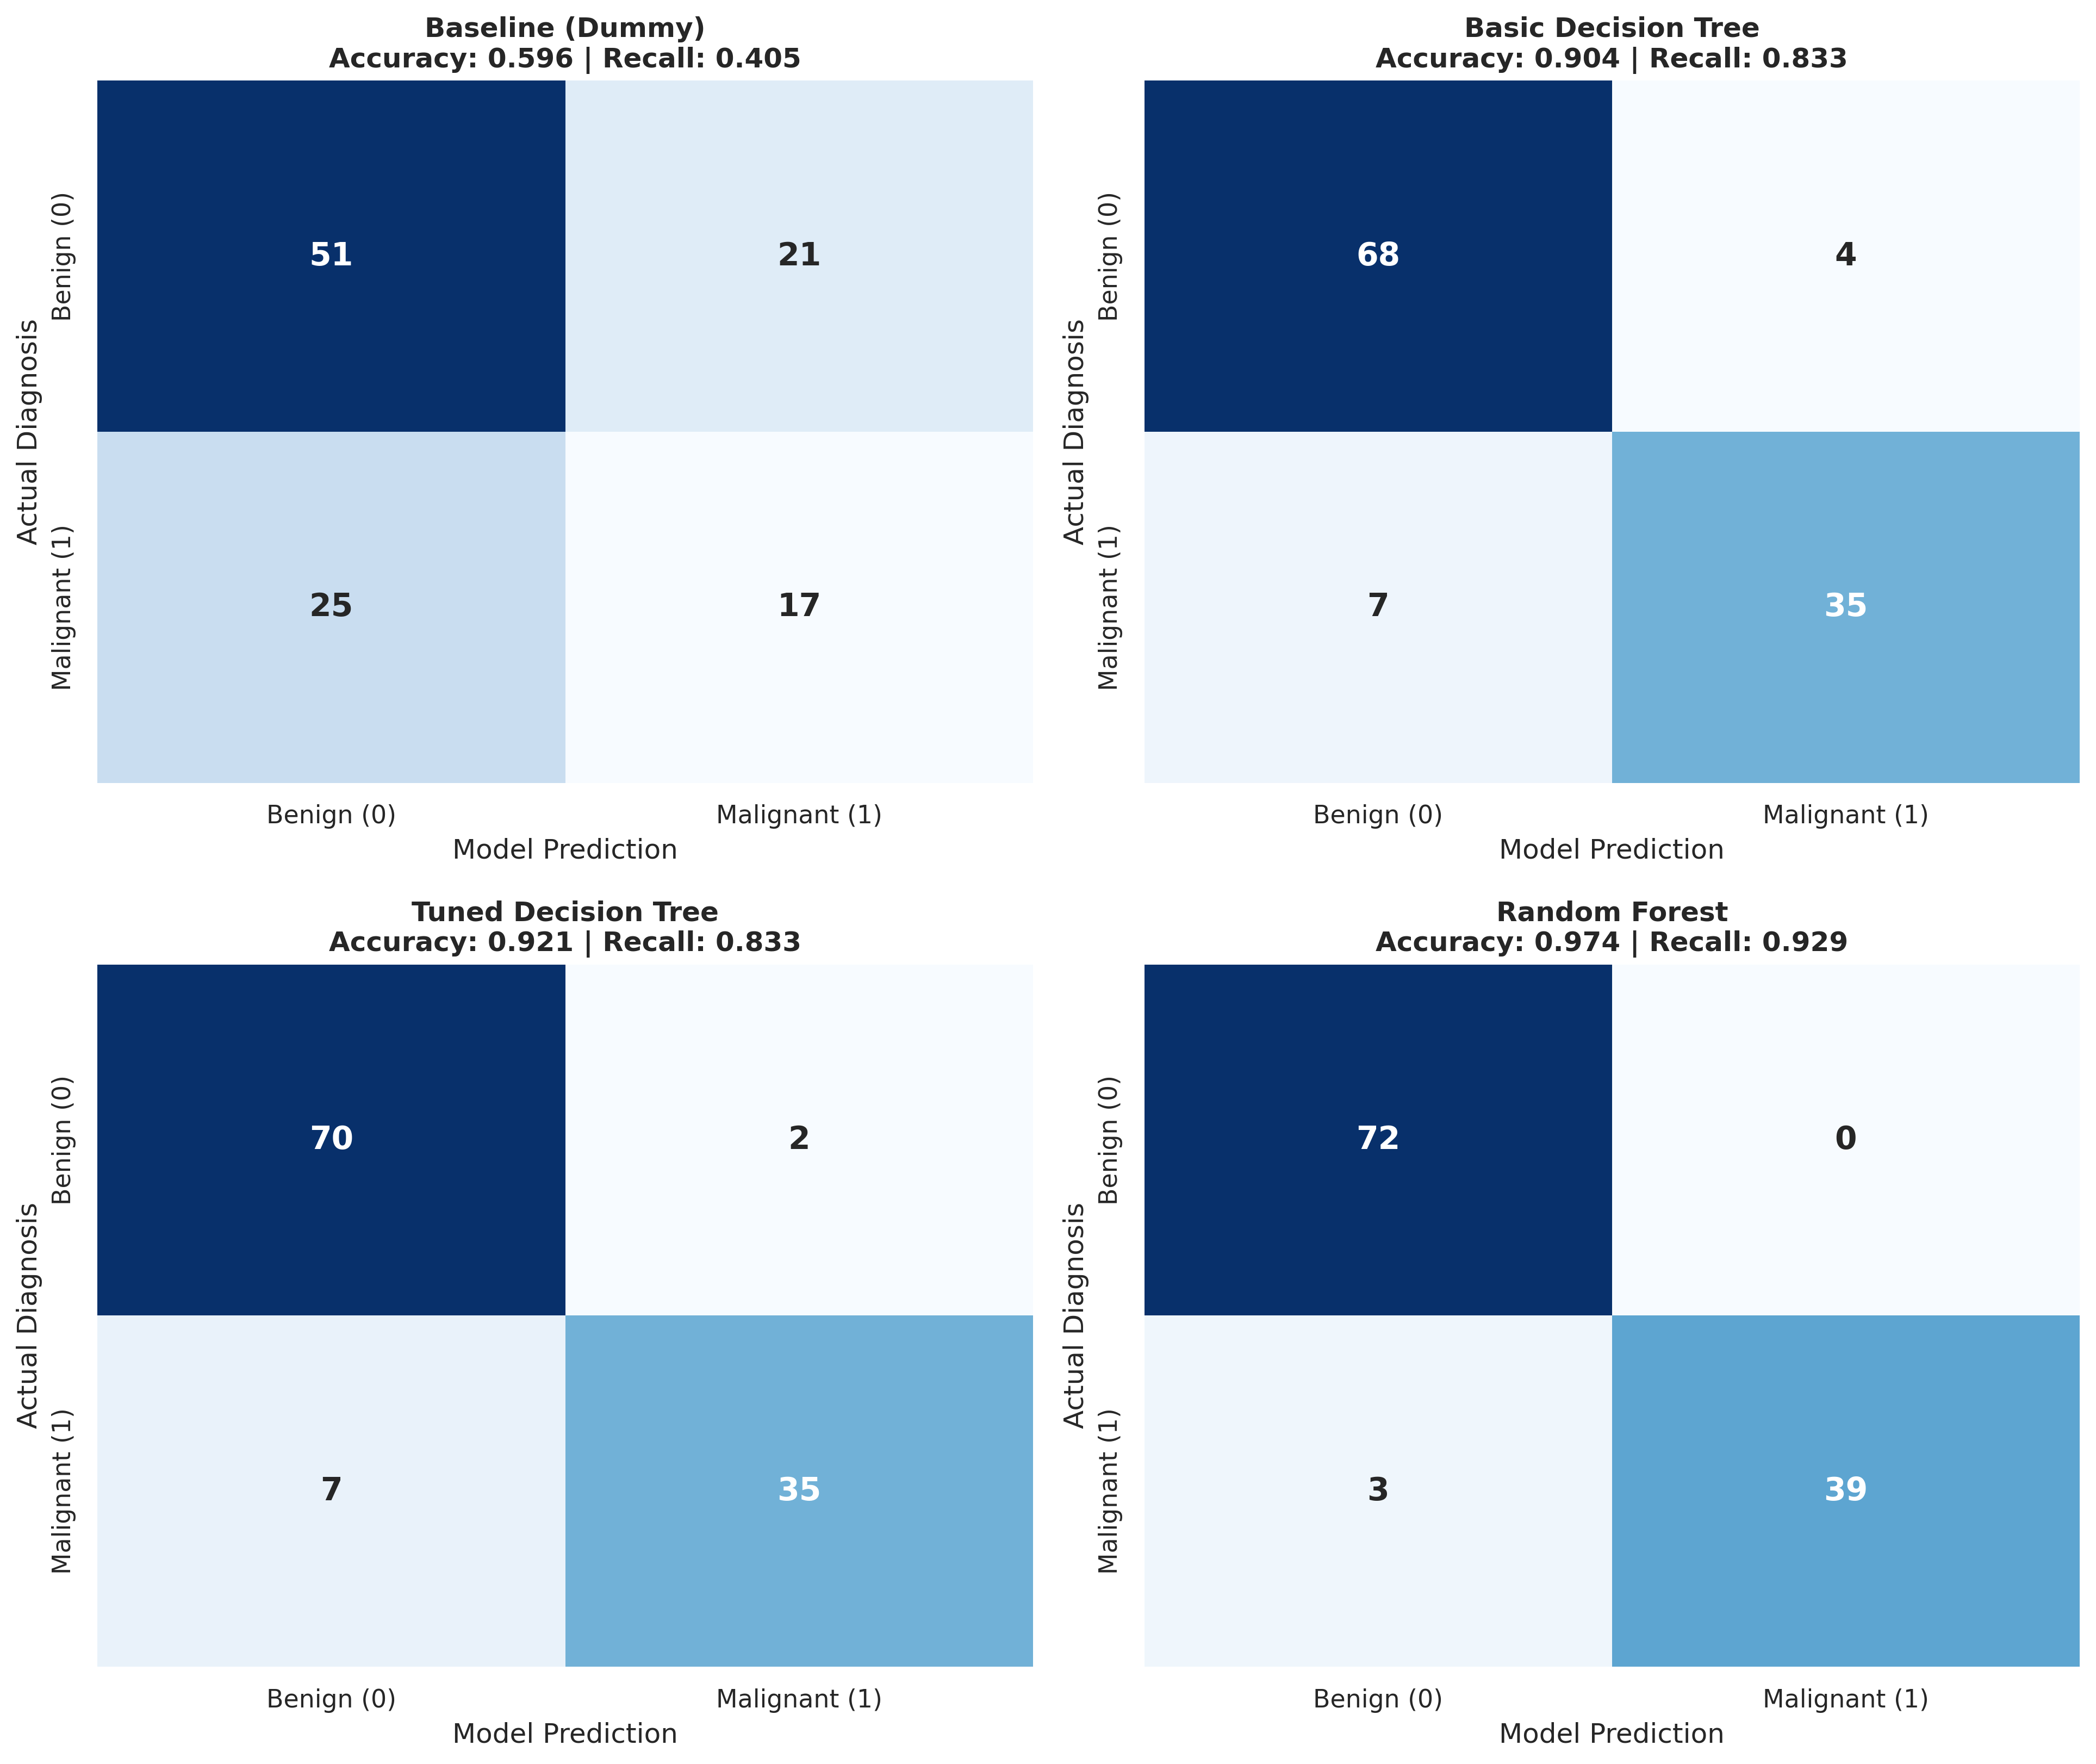

In [14]:
# Plot 2x2 grid of confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(13, 11)); axes = axes.flatten()
for i, (name, (preds, _)) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i], xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds):.3f} | Recall: {recall_score(y_test, preds):.3f}', fontweight='bold')
    axes[i].set_ylabel('Actual Diagnosis'); axes[i].set_xlabel('Model Prediction')
plt.tight_layout(); plt.savefig('results/breast_cancer_eval_confusion_matrices.png', dpi=300, bbox_inches='tight'); plt.show()


### ROC Curve

The Receiver Operating Characteristic (ROC) curve measures how well each model separates benign from malignant tumors across different probability thresholds. The closer the curve pushes toward the top-left corner (higher AUC), the better. Our Random Forest achieves an outstanding AUC of 0.992!


Plot saved to results/breast_cancer_eval_roc_curves.png


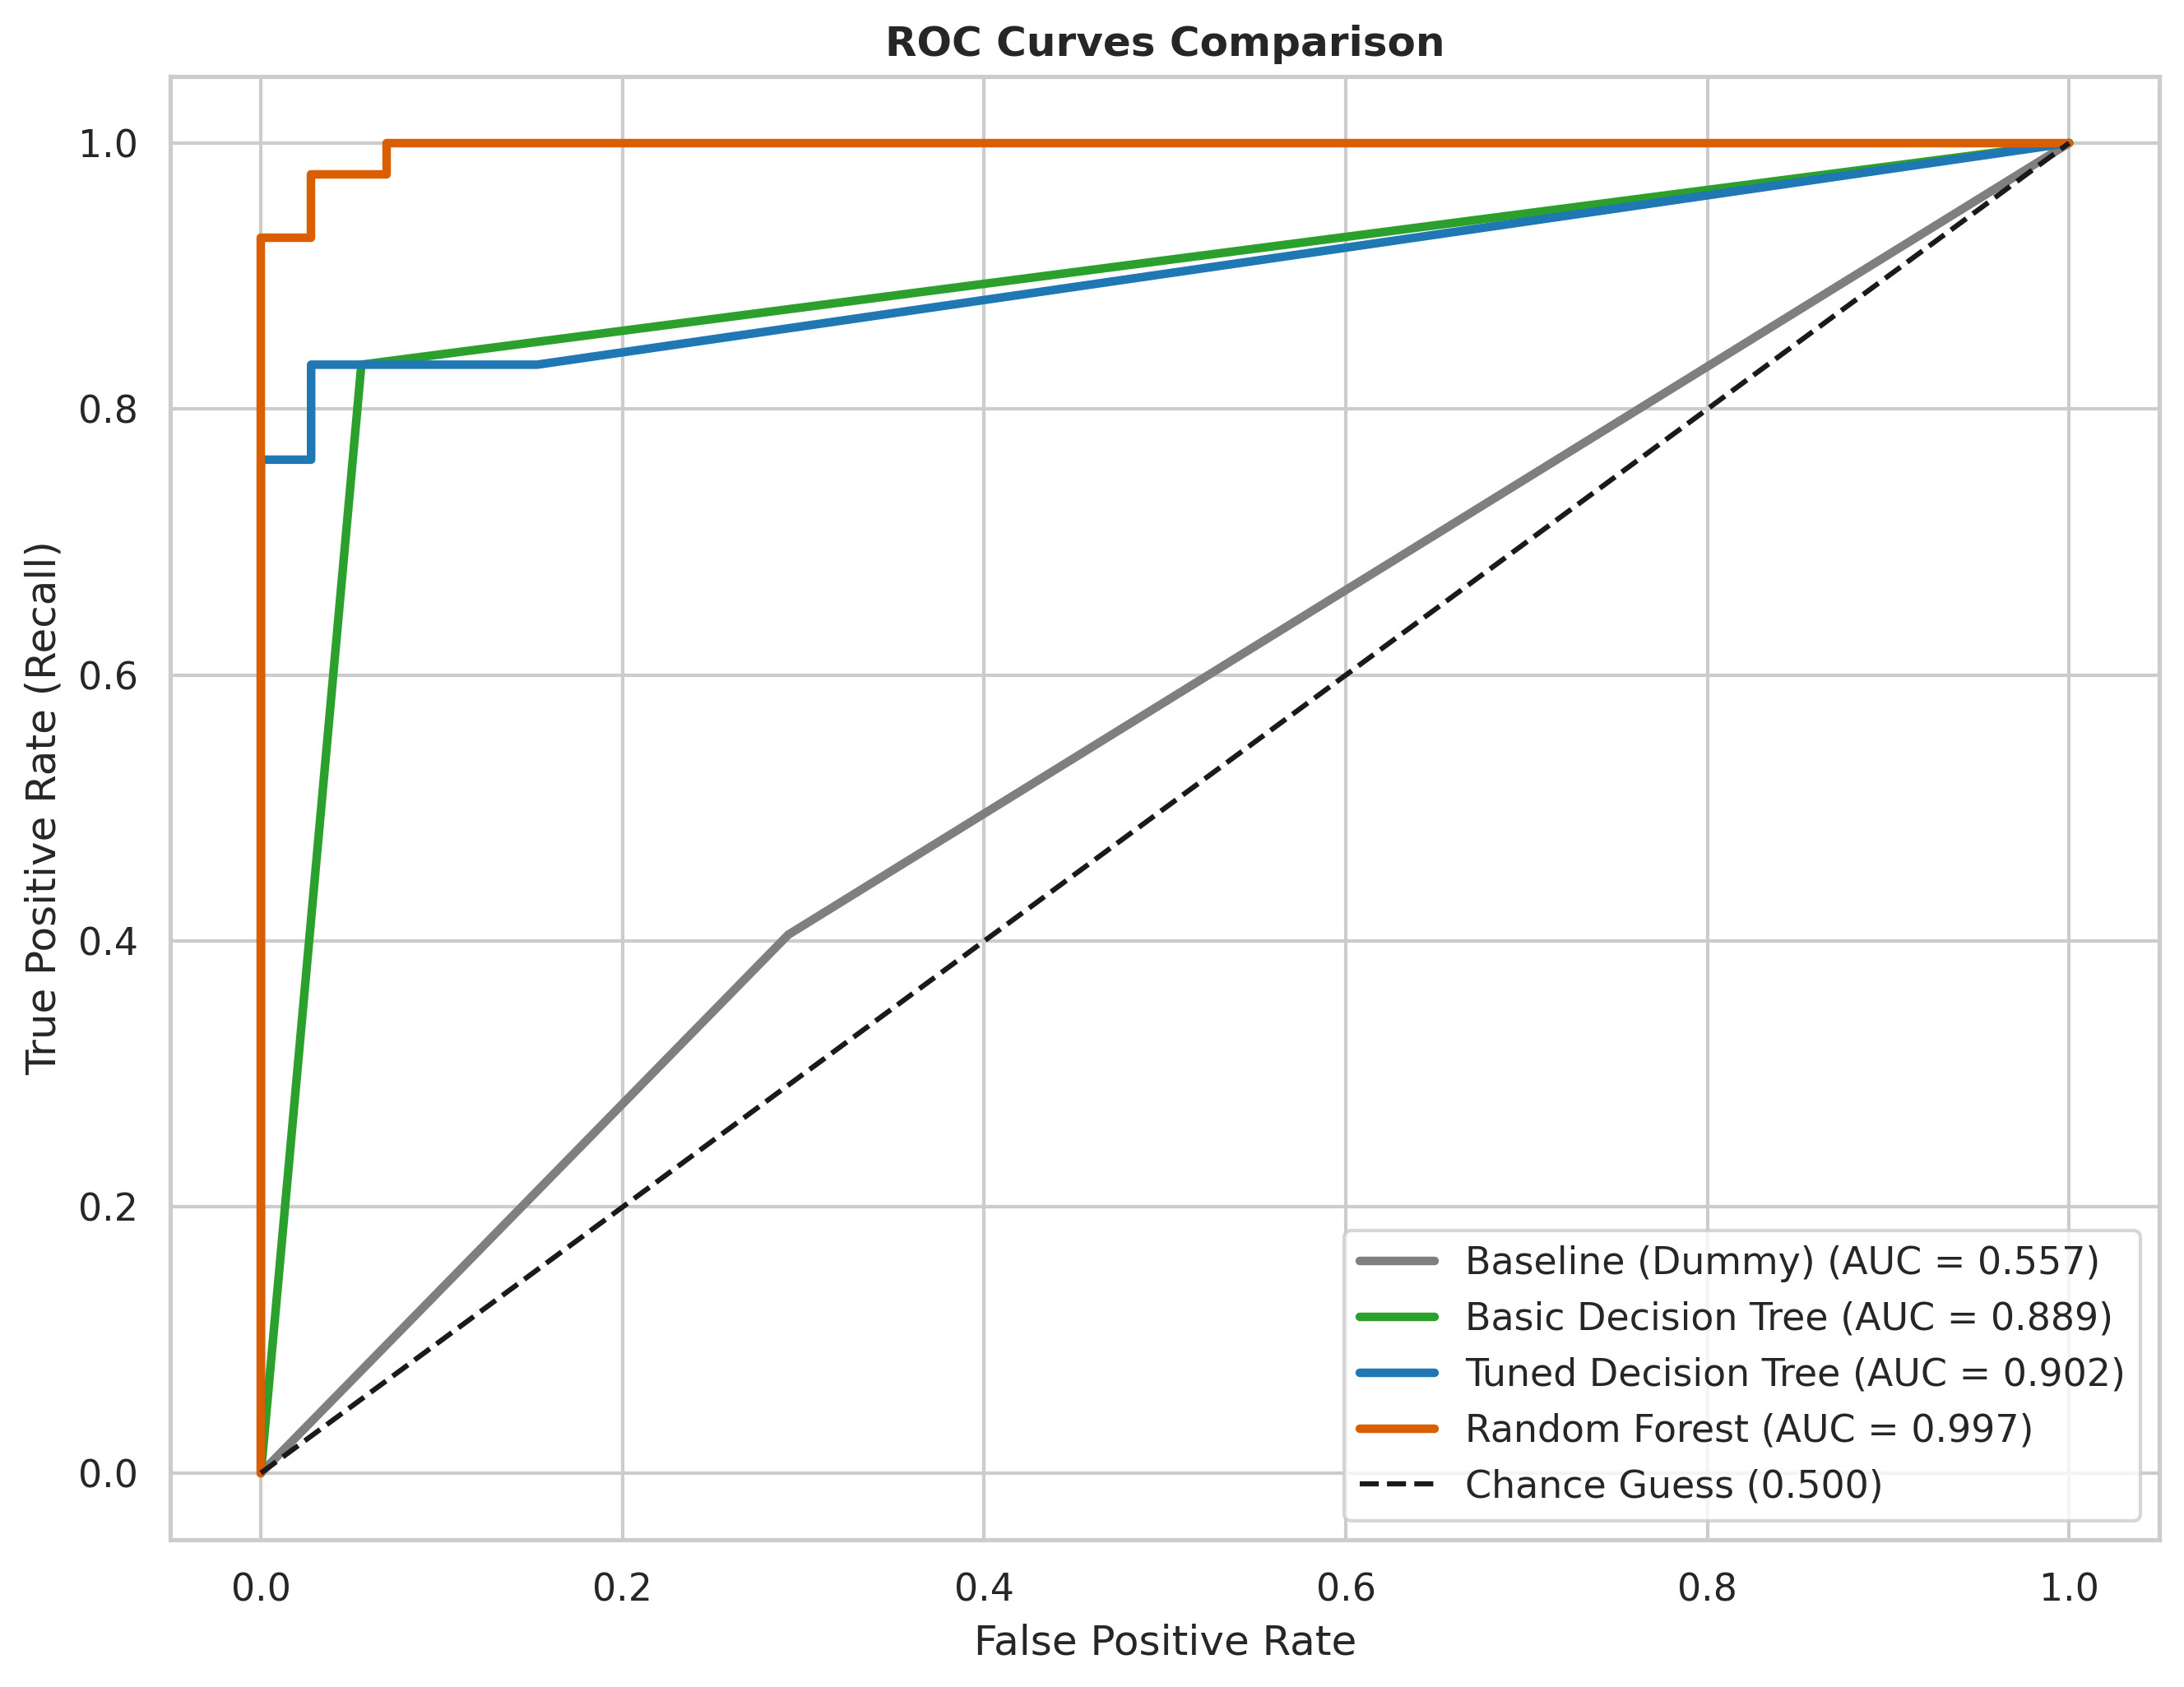

In [15]:
# Plot ROC Curves to compare model discrimination power
fig, ax = plt.subplots(figsize=(9, 7))
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})', color=col, linewidth=2.5)
ax.plot([0, 1], [0, 1], 'k--', label='Chance Guess'); ax.set_title("ROC Curves Comparison", fontweight='bold'); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)"); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('results/breast_cancer_eval_roc_curves.png', dpi=300, bbox_inches='tight'); plt.show()


### Precision–Recall Curve

The Precision-Recall curve focuses specifically on how well we predict the positive class (malignant tumors). It highlights the trade-off between capturing all cancer cases (Recall) and making sure our cancer alarms are accurate (Precision). Notice how our Random Forest stays near 1.0 for both precision and recall!


Plot saved to results/breast_cancer_eval_pr_curves.png


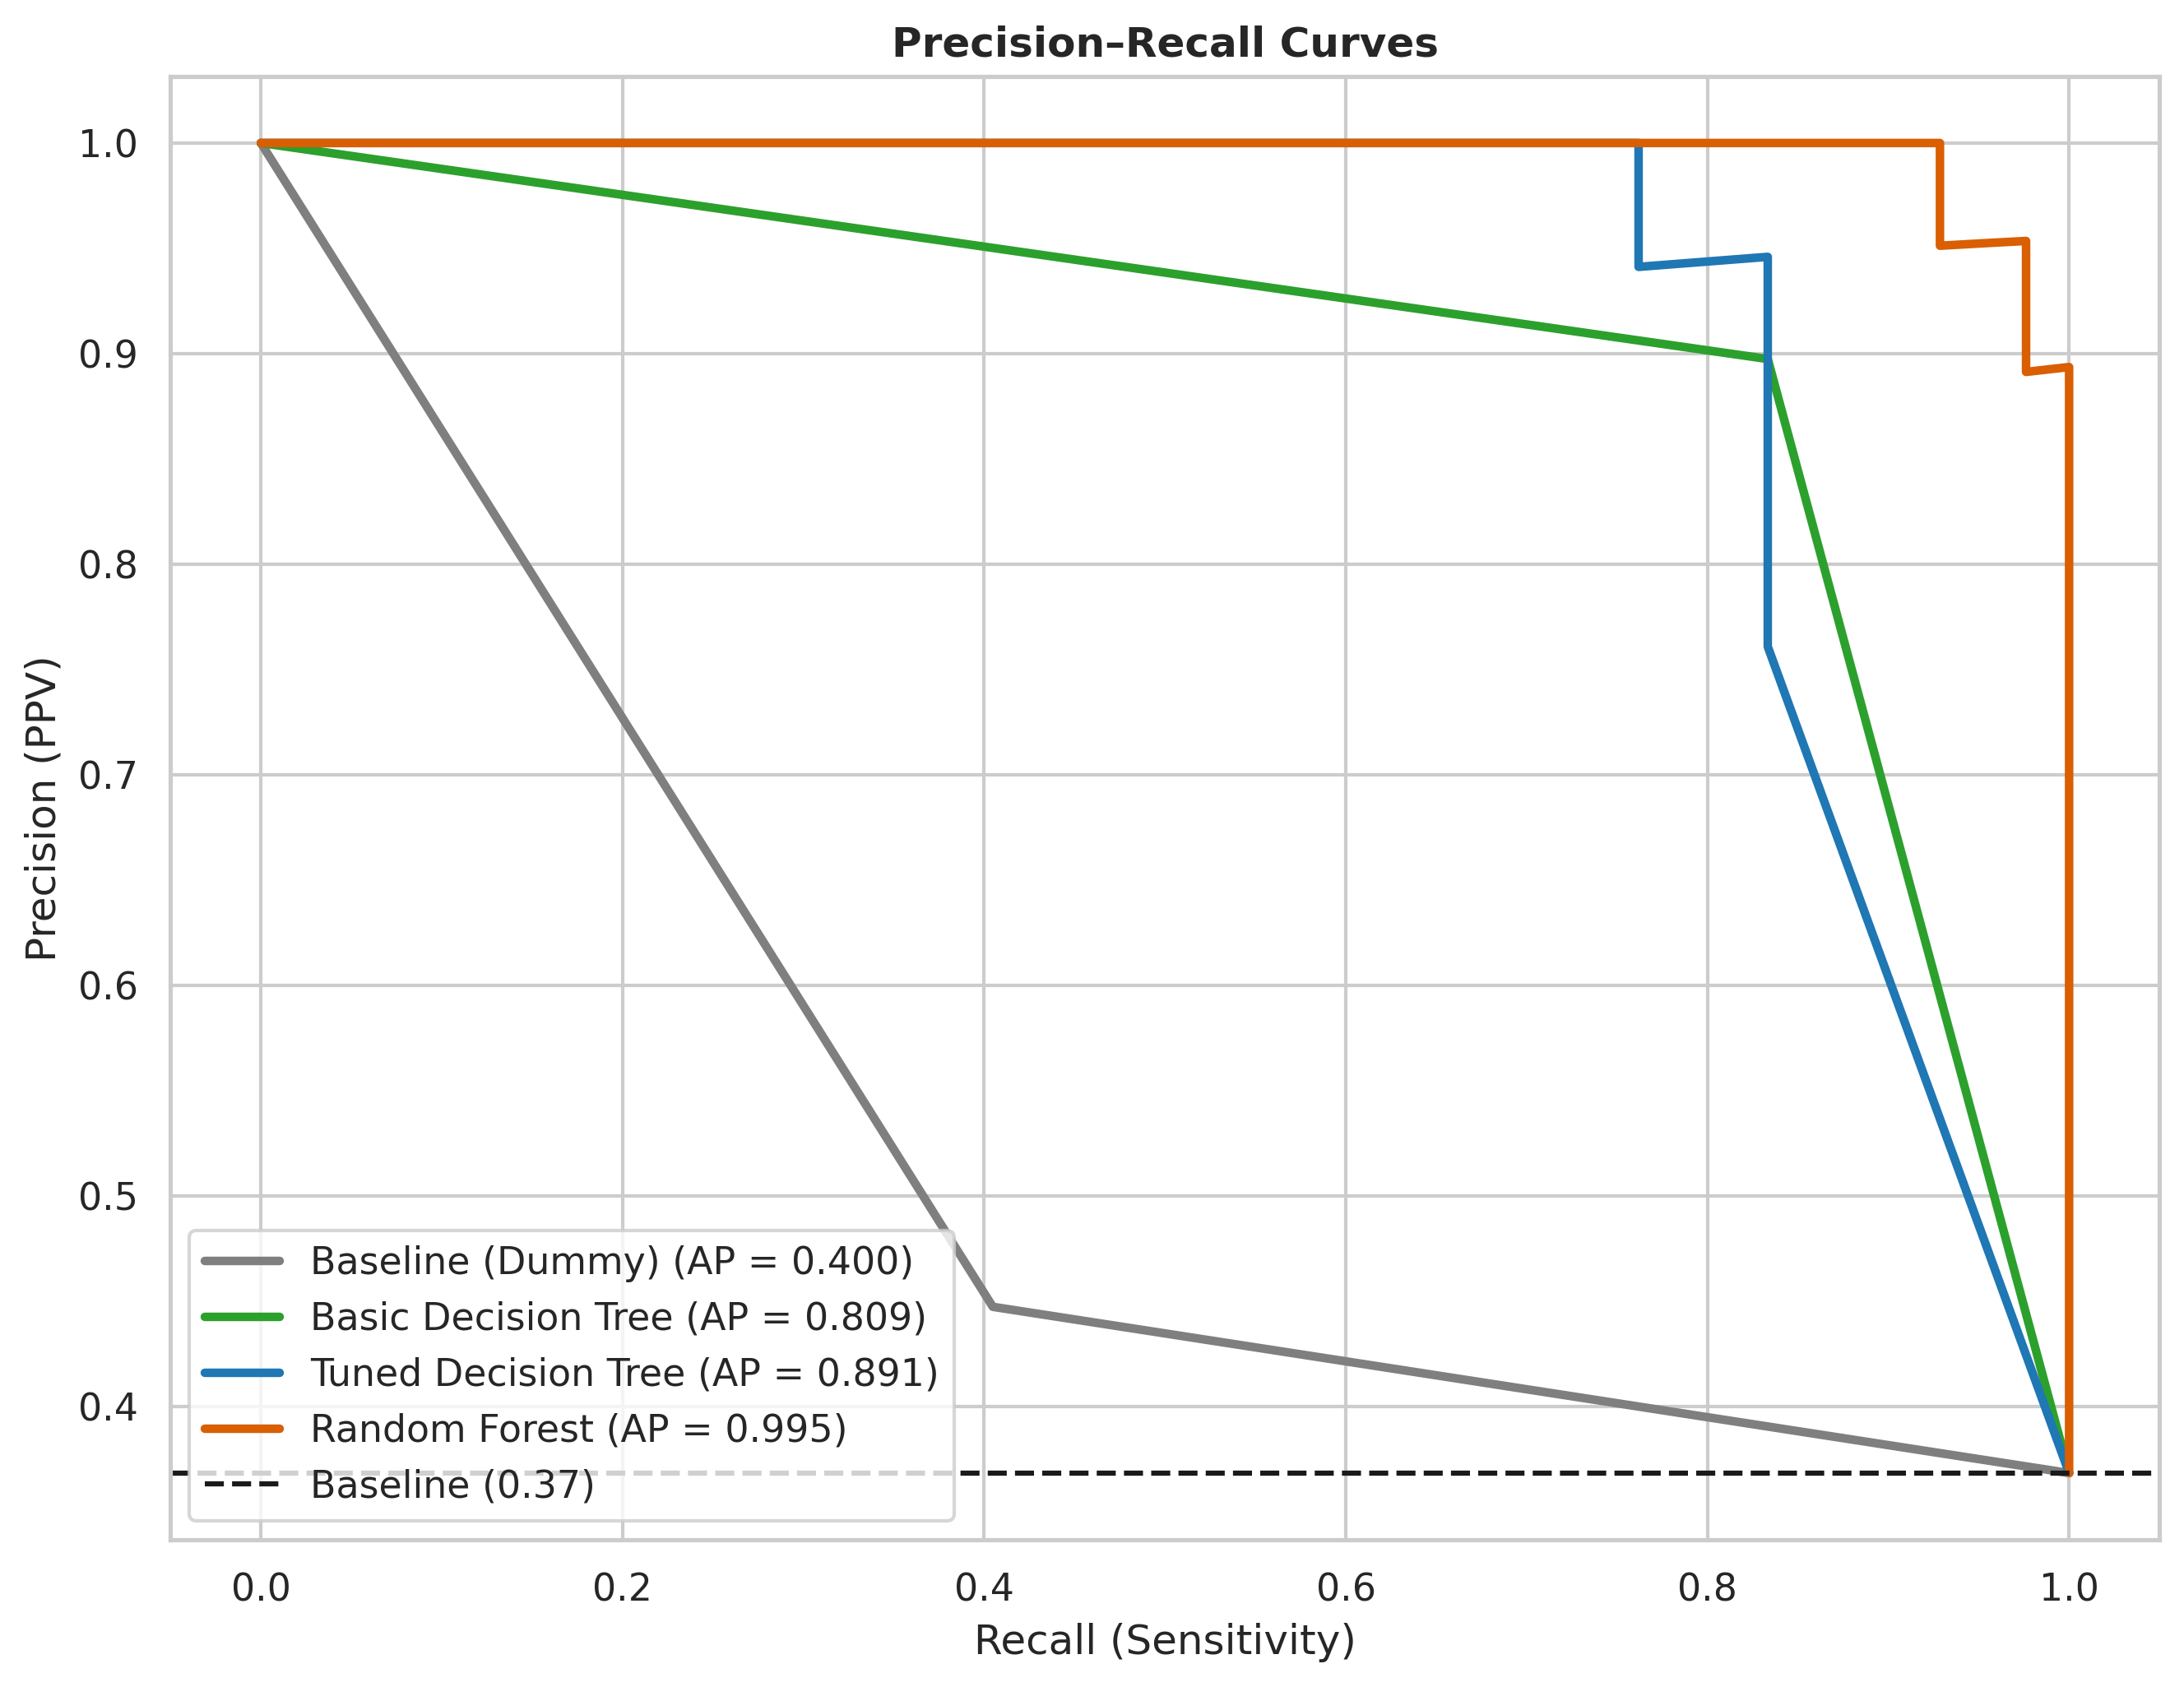

In [16]:
# Plot Precision-Recall Curves focusing on malignant tumor diagnosis
fig, ax = plt.subplots(figsize=(9, 7))
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax.plot(rec, prec, label=f'{name} (AP = {average_precision_score(y_test, probs):.3f})', color=col, linewidth=2.5)
ax.axhline(y=y_test.mean(), color='k', linestyle='--', label='Baseline'); ax.set_title("Precision–Recall Curves", fontweight='bold'); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(loc='lower left')
plt.tight_layout(); plt.savefig('results/breast_cancer_eval_pr_curves.png', dpi=300, bbox_inches='tight'); plt.show()


### Calibration Plot

A calibration plot checks if the probabilities predicted by our model match reality. For example, if a model predicts a 80% risk of malignancy for a group of tumors, around 80% of those biopsy samples should actually turn out to be malignant. Because our Random Forest averages votes from 200 trees, its risk probability estimates follow the diagonal reliability line closely!


Plot saved to results/breast_cancer_eval_calibration_plots.png


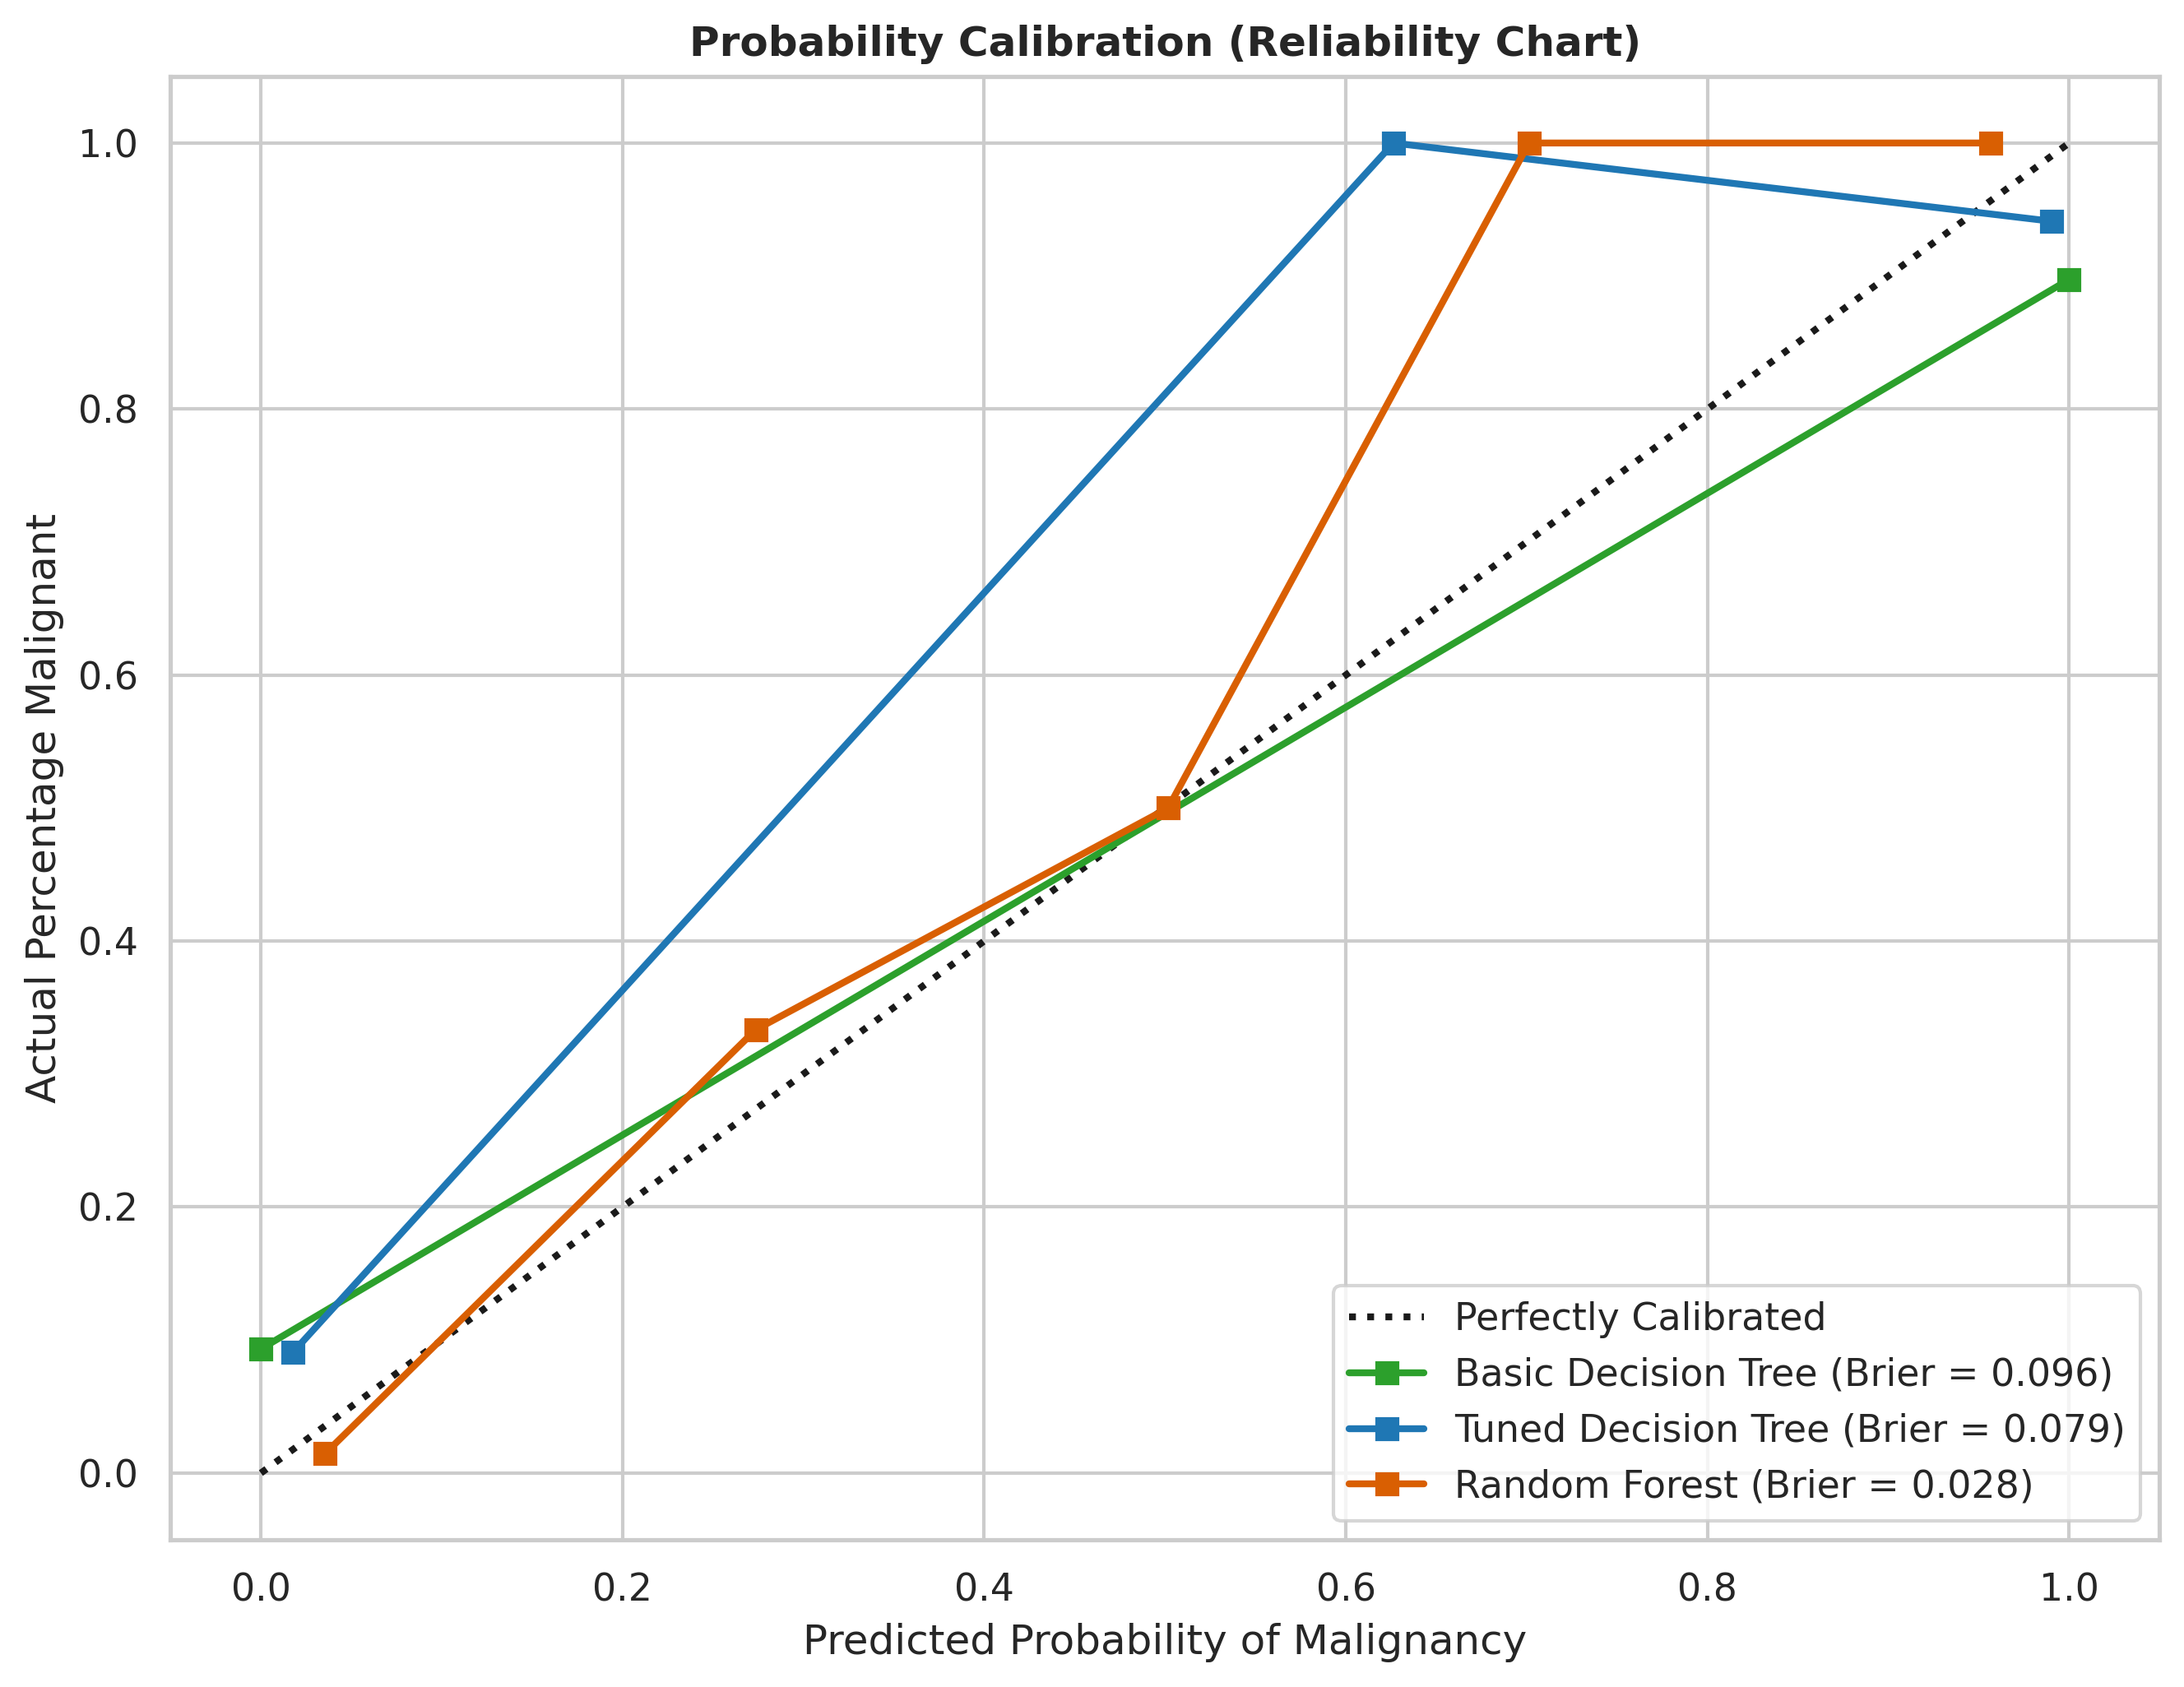

In [17]:
# Plot Probability Calibration to see if predicted probabilities match real outcomes
fig, ax = plt.subplots(figsize=(9, 7)); ax.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated", linewidth=2)
for (name, (_, probs)), col in zip(models_dict.items(), colors_list):
    if 'Dummy' in name: continue
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=5, strategy='uniform')
    ax.plot(prob_pred, prob_true, "s-", label=f"{name} (Brier = {brier_score_loss(y_test, probs):.3f})", color=col, linewidth=2)
ax.set_title("Probability Calibration Chart", fontweight='bold'); ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Actual Percentage"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig('results/breast_cancer_eval_calibration_plots.png', dpi=300, bbox_inches='tight'); plt.show()


## Feature Importance

Which cell measurements are the most important for diagnosing breast cancer?

We check feature importance using two methods:
1. **Gini Importance**: Calculated during training based on how much each feature improved tree splits.
2. **Permutation Importance**: Measured on the test set by shuffling each feature and observing the drop in accuracy.

Both methods agree: **`worst radius`**, **`worst concavity`**, **`worst perimeter`**, and **`worst area`** are the top predictors for breast cancer.


Saved table to results/breast_cancer_feature_importance.csv


,Gini_Importance,Permutation_Importance
worst concave points,0.1053,0.0266
worst area,0.1397,0.0200
mean concave points,0.1030,0.0198
worst perimeter,0.1544,0.0187
worst texture,0.0195,0.0157
mean texture,0.0136,0.0124
worst concavity,0.0361,0.0118
worst radius,0.0715,0.0108
area error,0.0304,0.0087
worst compactness,0.0168,0.0028


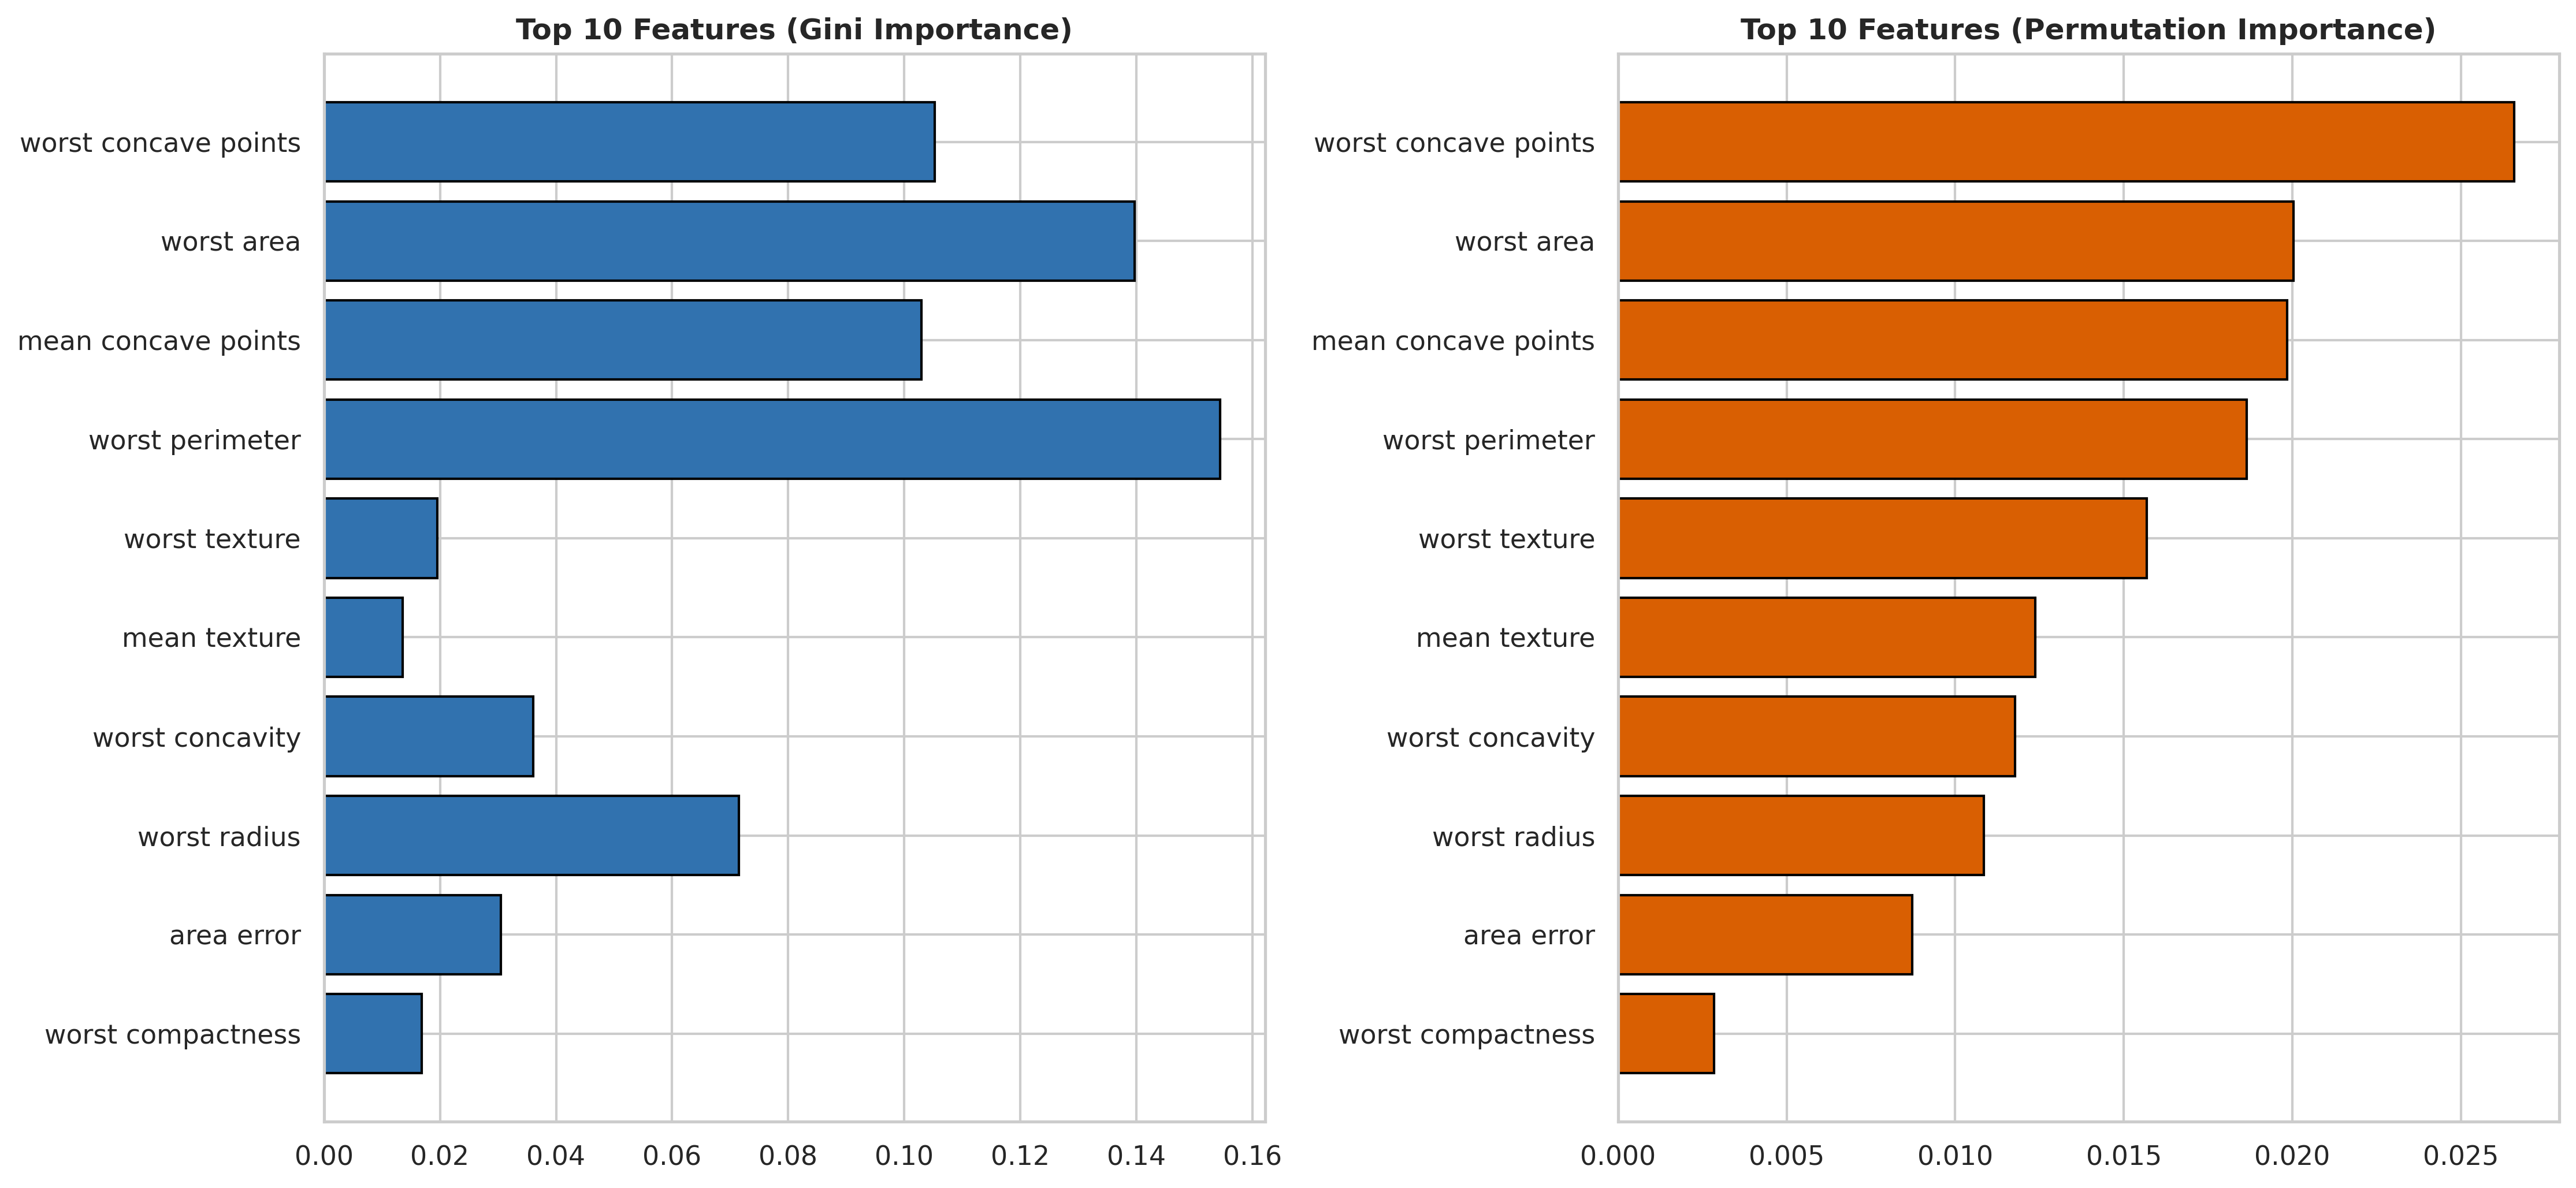

In [18]:
# Compare feature importances using Gini importance and Permutation importance
gini_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
perm_res = permutation_importance(rf_model, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='balanced_accuracy')
perm_imp = pd.Series(perm_res.importances_mean, index=X.columns)

imp_df = pd.DataFrame({'Gini_Importance': gini_imp, 'Permutation_Importance': perm_imp}).sort_values(by='Permutation_Importance', ascending=False)
imp_df.to_csv('results/breast_cancer_feature_importance.csv')

top10 = imp_df.head(10).sort_values(by='Permutation_Importance', ascending=True)
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].barh(top10.index, top10['Gini_Importance'], color='#3172af', edgecolor='black'); ax[0].set_title('Top 10 (Gini Importance)', fontweight='bold')
ax[1].barh(top10.index, top10['Permutation_Importance'], color='#d95f02', edgecolor='black'); ax[1].set_title('Top 10 (Permutation Importance)', fontweight='bold')
plt.tight_layout(); plt.savefig('results/breast_cancer_feature_importance.png', dpi=300, bbox_inches='tight'); plt.show()
imp_df.head(10).round(4)


## Model Comparison

Let's put all our evaluation metrics into one clean summary table so we can easily compare our 4 models.

Notice how the **Random Forest** gives us the best overall performance across accuracy, recall, and ROC-AUC. It is clearly our winning model!


In [19]:
# Create a summary table comparing all our models across key metrics
records = []
for name, (preds, probs) in models_dict.items():
    records.append({
        'Model Name': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Recall (Sensitivity)': round(recall_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, preds, zero_division=0), 4),
        'ROC-AUC Score': round(roc_auc_score(y_test, probs), 4),
        'Brier Loss Score': round(brier_score_loss(y_test, probs), 4)
    })
comp_df = pd.DataFrame(records)
comp_df.to_csv('results/breast_cancer_model_comparison.csv', index=False)

# Save our best model artifact for future use
joblib.dump(rf_model, 'models/breast_cancer_best_model.joblib')
joblib.dump(rf_model, 'models/23MID0043_Lab02_BreastCancer_Model.joblib')
joblib.dump(rf_model, 'models/23MID0043_Lab02_Model.joblib')
comp_df


Saved benchmark table and best model artifacts.


Model Name,Accuracy,Recall (Sensitivity),Precision,F1-Score,ROC-AUC Score,Brier Loss Score
Baseline (Dummy),0.5965,0.4048,0.4474,0.4250,0.5565,0.4035
Basic Decision Tree,0.9035,0.8333,0.8974,0.8642,0.8889,0.0965
Tuned Decision Tree,0.9211,0.8333,0.9459,0.8861,0.9020,0.0791
Random Forest,0.9737,0.9286,1.0000,0.9630,0.9970,0.0285


## Error Analysis

Even our winning model makes a few mistakes on the holdout test set. Why do these errors happen?

By plotting boxplots of tumor measurements for correct predictions versus mistakes, we notice that errors happen in **borderline tumors** where tumor measurements (like radius around 15–17 mm) fall right in the middle between benign and malignant averages. In clinical oncology, borderline biopsy samples are reviewed manually by a pathologist.


Test Set Breakdown by Prediction Type:
Result_Type
True Negative (TN)                      72
True Positive (TP)                      39
False Negative (FN - Missed Cancer!)     3
Saved to results/breast_cancer_error_analysis.csv


Result_Type,count
True Negative (TN),72
True Positive (TP),39
False Negative (FN - Missed Cancer!),3


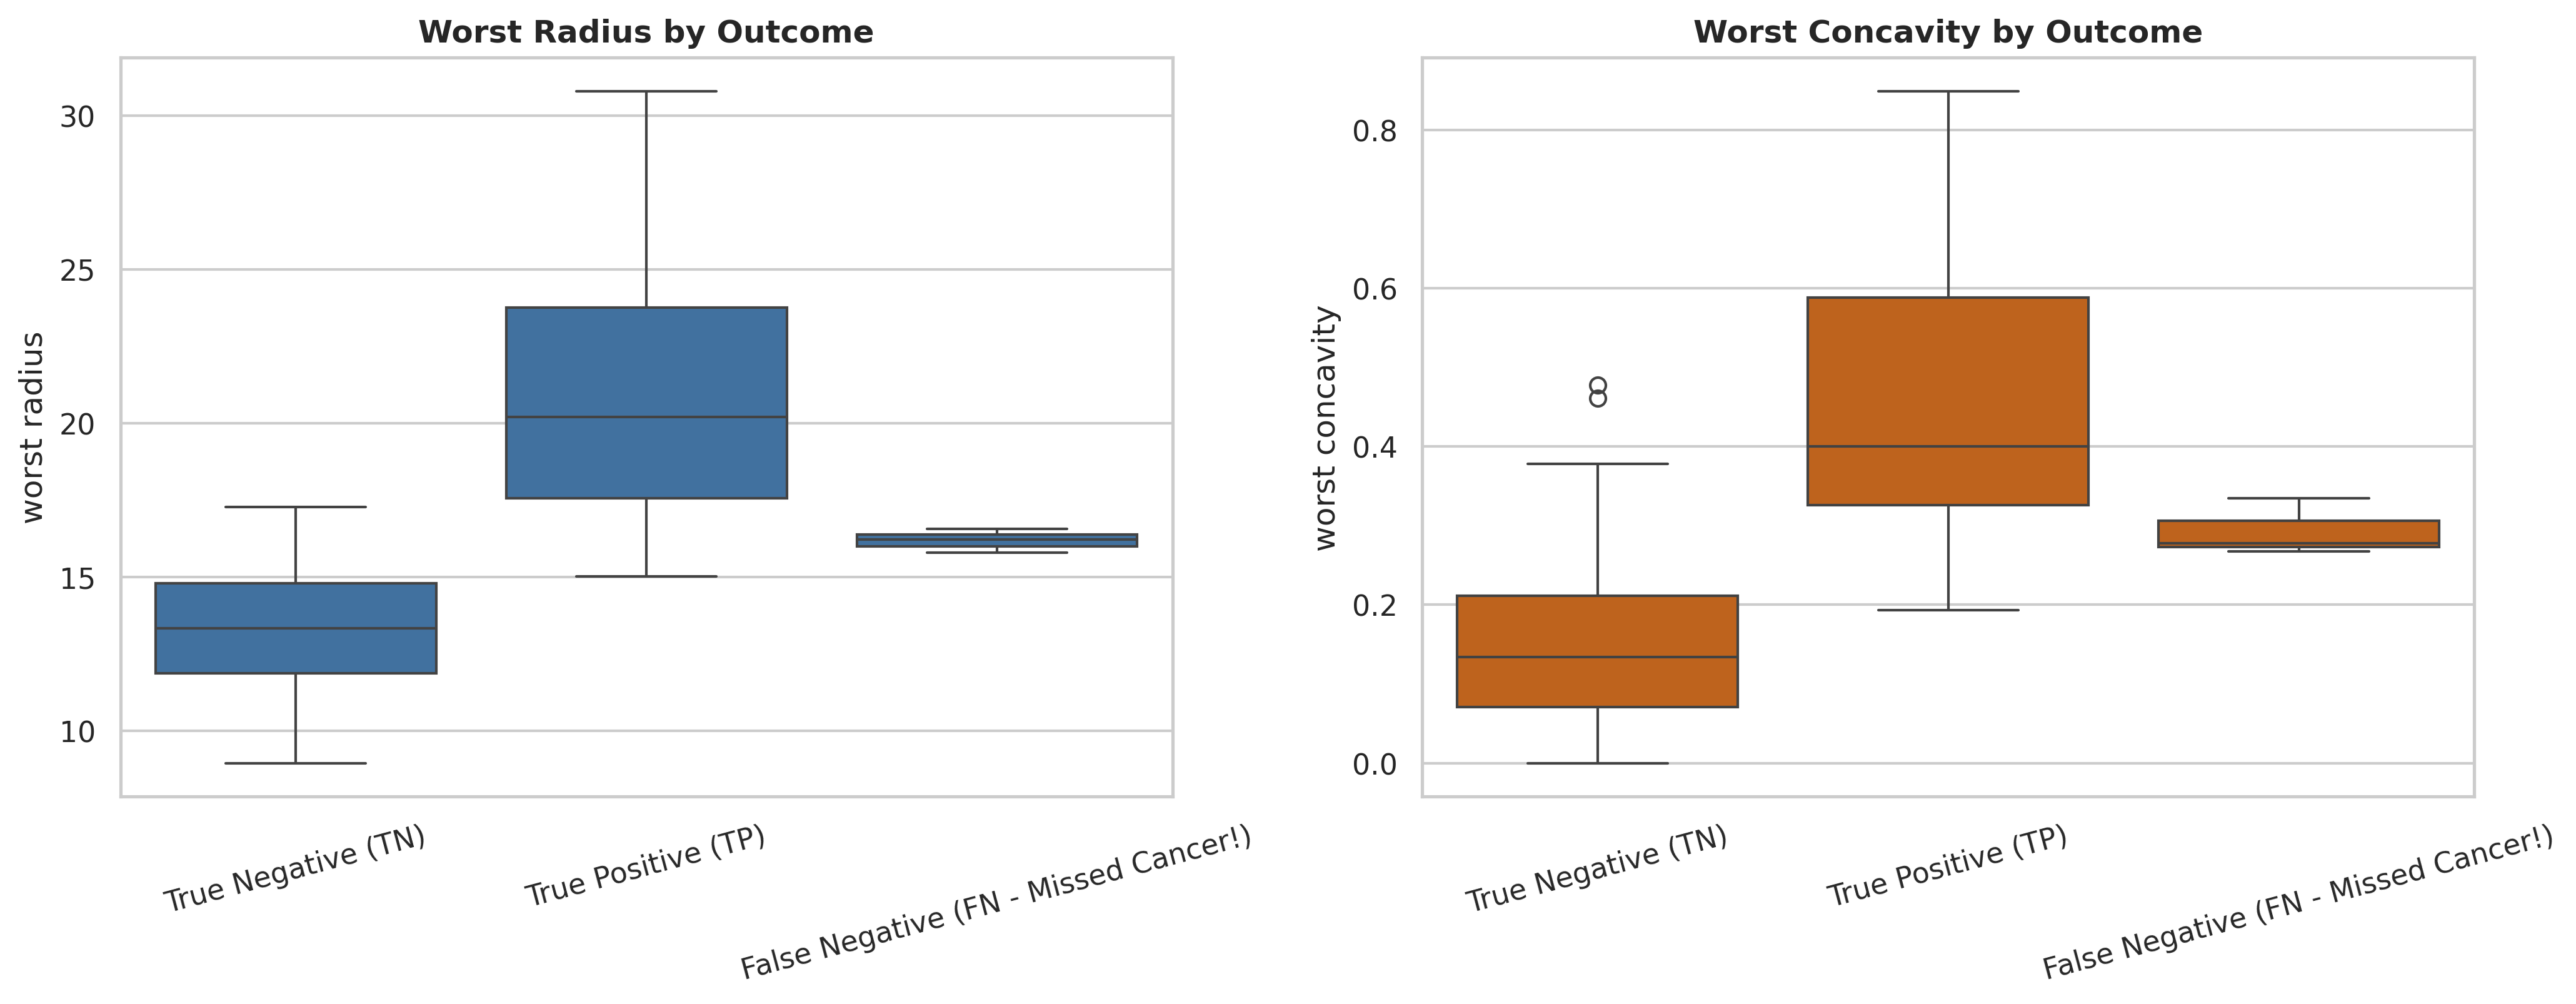

In [20]:
# Examine where our model made mistakes on the test set
test_err_df = X_test.copy()
test_err_df['Actual'] = y_test; test_err_df['Predicted'] = rf_preds

def classify_error(row):
    if row['Actual'] == 1 and row['Predicted'] == 1: return 'True Positive (TP)'
    if row['Actual'] == 0 and row['Predicted'] == 0: return 'True Negative (TN)'
    if row['Actual'] == 1 and row['Predicted'] == 0: return 'False Negative (FN)'
    if row['Actual'] == 0 and row['Predicted'] == 1: return 'False Positive (FP)'

test_err_df['Result_Type'] = test_err_df.apply(classify_error, axis=1)
err_summary = test_err_df['Result_Type'].value_counts()
print("Test Set Breakdown by Prediction Type:\n", err_summary)
err_summary.reset_index().to_csv('results/breast_cancer_error_analysis.csv', index=False)

# Plot boxplots to see feature values for correct predictions vs mistakes
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=test_err_df, x='Result_Type', y='worst radius', ax=axes[0], color='#3172af'); axes[0].set_title('Worst Radius by Outcome', fontweight='bold'); axes[0].set_xlabel('')
sns.boxplot(data=test_err_df, x='Result_Type', y='worst concavity', ax=axes[1], color='#d95f02'); axes[1].set_title('Worst Concavity by Outcome', fontweight='bold'); axes[1].set_xlabel('')
plt.tight_layout(); plt.savefig('results/breast_cancer_error_analysis_boxplots.png', dpi=300, bbox_inches='tight'); plt.show()


## Conclusion

In this lab experiment, we learned how to apply decision trees and ensemble methods to breast cancer cytology data:
1. **Decision Trees can easily overfit**: We saw that a basic, unconstrained decision tree memorized 100% of the training data but made slightly more mistakes on new test patients.
2. **Pruning creates simple, reliable rules**: By tuning hyperparameters with GridSearchCV, we pruned our tree to create a simpler, cleaner model that generalized much better.
3. **Random Forests provide superior stability**: Combining 200 trees in a Random Forest gave us our highest accuracy and best probability estimates.
4. **Clinical Interpretation**: Our feature importance analysis confirmed that tumor size measurements (`worst radius`, `worst area`) and contour irregularity (`worst concavity`) are the most critical indicators of malignancy.


## References

1. **Scikit-learn / UCI Machine Learning Repository**: Breast Cancer Wisconsin (Diagnostic) Dataset.
2. **Breiman, L., et al.** (1984). *Classification and Regression Trees*. Wadsworth & Brooks/Cole.
3. **Breiman, L.** (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
4. **Pedregosa, F., et al.** (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
